# Computational prediction of malachite green binding to candidate *Bacillus subtilis* enzymes using consensus molecular docking

Mount Google Drive so this work persists permanently across sessions

Create the project folder structure directly on Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os, shutil, stat

In [ ]:
base = '/content/drive/MyDrive/MG_docking_project'
for sub in ['01_ligand', '02_receptors/raw_pdb', '02_receptors/prepared_pdbqt',
            '03_docking/vina', '03_docking/smina', '03_docking/swissdock',
            '04_analysis/scores', '04_analysis/poses', '04_analysis/figures',
            '05_manuscript']:
    os.makedirs(f'{base}/{sub}', exist_ok=True)
print("Project structure created at", base)

Project structure created at /content/drive/MyDrive/MG_docking_project


In [ ]:
!pwd

/content


Make the project folder as the working directory, using the `%cd` magic command (with `%`, not `!`) to actually make the new directory Colab's persistent working directory for the rest of the session. If `!` is used, Colab reverts to `/content` immediately in the next cell.

In [ ]:
%cd /content/drive/MyDrive/MG_docking_project

/content/drive/MyDrive/MG_docking_project


In [ ]:
!pwd

/content/drive/MyDrive/MG_docking_project


Good!

From here, run %cd once like this at the top of every new session (right after mounting Drive), and every relative path will resolve correctly from there for the rest of that session. No need to repeat %cd in every cell.

### Install the toolchain

In [ ]:
# ============================================================
# Docking environment setup — installs directly into this Colab session
# Engines: AutoDock Vina, Smina, LeDock  |  Pocket ID: fpocket
# ============================================================

PROJECT_DIR = "/content/drive/MyDrive/MG_docking_project"
BIN_DIR = f"{PROJECT_DIR}/bin"
os.makedirs(BIN_DIR, exist_ok=True)

# ---- 1. apt: openbabel + build tools (for fpocket compile) ----
!apt-get update -qq
!apt-get install -y -qq openbabel build-essential git wget

# ---- 2. pip: python-side cheminformatics/docking libs ----
!pip install -q meeko rdkit biopython pandas seaborn py3Dmol plip vina

# ---- 3. AutoDock Vina CLI binary (prebuilt, no compile) ----
vina_path = f"{BIN_DIR}/vina"
if not os.path.exists(vina_path):
    !wget -q -O {vina_path} https://github.com/ccsb-scripps/AutoDock-Vina/releases/download/v1.2.5/vina_1.2.5_linux_x86_64
    os.chmod(vina_path, 0o755)

# ---- 4. Smina (prebuilt static binary) ----
smina_path = f"{BIN_DIR}/smina"
if not os.path.exists(smina_path):
    !wget -q -O {smina_path} https://sourceforge.net/projects/smina/files/smina.static/download
    os.chmod(smina_path, 0o755)

# ---- 5. fpocket (compiled from source — minimal deps, quick build) ----
fpocket_path = f"{BIN_DIR}/fpocket"
if not os.path.exists(fpocket_path):
    !git clone -q --depth 1 https://github.com/Discngine/fpocket.git /content/fpocket_src
    !cd /content/fpocket_src && make -s 2>&1 | tail -5
    shutil.copy("/content/fpocket_src/bin/fpocket", fpocket_path)
    os.chmod(fpocket_path, 0o755)

# ---- 6. LeDock + LePro (4th engine, chosen over rDock) ----
ledock_path = f"{BIN_DIR}/ledock"
lepro_path  = f"{BIN_DIR}/lepro"
if not os.path.exists(ledock_path):
    !wget -q -O {ledock_path} http://www.lephar.com/download/ledock_linux_x86
    !wget -q -O {lepro_path}  http://www.lephar.com/download/lepro_linux_x86
    os.chmod(ledock_path, 0o755)
    os.chmod(lepro_path, 0o755)

# ---- 7. Put project bin/ on PATH for this session ----
os.environ["PATH"] = f"{BIN_DIR}:" + os.environ["PATH"]

# ---- 8. Sanity check every engine resolves ----
for exe in ["obabel", "vina", "smina", "fpocket", "ledock", "lepro"]:
    print(f"{exe:10s} -> {shutil.which(exe) or 'NOT FOUND'}")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package libboost-iostreams1.74.0:amd64.
(Reading database ... 118419 files and directories currently installed.)
Preparing to unpack .../libboost-iostreams1.74.0_1.74.0-14ubuntu3_amd64.deb ...
Unpacking libboost-iostreams1.74.0:amd64 (1.74.0-14ubuntu3) ...
Selecting previously unselected package libinchi1.
Preparing to unpack .../libinchi1_1.03+dfsg-4_amd64.deb ...
Unpacking libinchi1 (1.03+dfsg-4) ...
Selecting previously unselected package libmaeparser1:amd64.
Preparing to unpack .../libmaeparser1_1.2.4-1build1_amd64.deb ...
Unpacking libmaeparser1:amd64 (1.2.4-1build1) ...
Selecting previously unselected package libopenbabel7.
Preparing to unpack .../libopenbabel7_3.1.1+dfsg-6ubuntu5_amd64.deb ...
Unpacking libopenbabel7 (3.1.1+dfsg-6ubuntu5) ...
Selecting previousl

In [ ]:
!pip install -q meeko gemmi rdkit biopython pandas seaborn py3Dmol plip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 76.4 MB/s eta 0:00:00


**What each piece does:**
| Tool | Role |
|---|---|
| `openbabel` | file format conversion, 3D conformer generation, protonation |
| `vina` (apt + pip) | Engine 1 — AutoDock Vina docking |
| `smina` | Engine 2 — independent empirical scoring function, same PDBQT format as Vina |
| `meeko` | modern ligand/receptor PDBQT preparation (replaces the old AutoDockTools GUI workflow) |
| `rdkit` | cheminformatics checks (formal charge verification, etc.) |
| `fpocket` | blind binding-pocket detection for receptors without a known ligand site |
| `py3Dmol` | in-notebook 3D structure visualisation (replaces a desktop PyMOL/ChimeraX window, which Colab can't display) |
| `plip` | protein–ligand interaction fingerprinting for Phase 5.4 |

In [ ]:
!pwd

/content/drive/MyDrive/MG_docking_project


In [ ]:
import subprocess

In [ ]:
# Create a local temporary directory for executables
LOCAL_BIN_DIR = "/tmp/local_bin"
os.makedirs(LOCAL_BIN_DIR, exist_ok=True)

# Copy executables from Google Drive to local temp directory and ensure permissions
# BIN_DIR is expected to be '/content/drive/MyDrive/MG_docking_project/bin'
executables_to_copy = ["vina", "smina", "ledock", "lepro", "fpocket"]
for exe in executables_to_copy:
    src_path = f"{BIN_DIR}/{exe}"
    dest_path = f"{LOCAL_BIN_DIR}/{exe}"
    if os.path.exists(src_path):
        shutil.copy(src_path, dest_path)
        os.chmod(dest_path, 0o755) # Ensure execute permissions on the local copy
    else:
        print(f"Warning: {src_path} not found. Skipping copy.")

# Now use the local executables for subprocess calls
print(subprocess.run([f'{LOCAL_BIN_DIR}/vina', '--version'], capture_output=True, text=True).stdout)
print(subprocess.run([f'{LOCAL_BIN_DIR}/smina', '--version'], capture_output=True, text=True).stdout)
print(subprocess.run(['obabel', '-V'], capture_output=True, text=True).stdout) # obabel is system-wide, no need to copy

# ledock / lepro have no --version flag — running with no args
# prints their banner to stdout and exits non-zero, which is expected.
ledock_check = subprocess.run([f'{LOCAL_BIN_DIR}/ledock'], capture_output=True, text=True)
print(ledock_check.stdout or ledock_check.stderr)

lepro_check = subprocess.run([f'{LOCAL_BIN_DIR}/lepro'], capture_output=True, text=True)
print(lepro_check.stdout or lepro_check.stderr)

# No change needed for Python libraries
import rdkit; print("RDKit OK:", rdkit.__version__)

import meeko; print("Meeko OK:", meeko.__version__)

import gemmi; print("gemmi OK:", gemmi.__version__)

AutoDock Vina v1.2.5

Smina Oct 15 2019.  Based on AutoDock Vina 1.1.2.

Open Babel 3.2.1 -- Jul 11 2026 -- 20:04:24

************************************************************
*       LeDock v1.0                                        *
*       Molecular Docking Software                         *
*       Copyright 2013-21 (C) H. Zhao PhD                  *
*       For academic use only                              *
*       www.lephar.com                                     *
************************************************************
--------Usage:
--------ledock config.file    !docking
--------ledock -spli dok.file !split into separate coordinates


************************************************************
*      LePro                                               *
*            Add hydrogen atoms to a protein &             *
*            write the input file for LeDock               *
*      Copyright (C) 2013-21 Hongtao Zhao, PhD             *
*      Email: htzhaovv@gmail.co

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Meeko OK: 0.7.1
gemmi OK: 0.7.5


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


AutoDock Vina v1.2.5

Smina Oct 15 2019.  Based on AutoDock Vina 1.1.2.

Open Babel 3.2.1 -- Jul 11 2026 -- 20:04:24

************************************************************
       LeDock v1.0                                        
       Molecular Docking Software                         
       Copyright 2013-21 (C) H. Zhao PhD                  
       For academic use only                              
       www.lephar.com                                     
************************************************************
      LePro                                               
      Add hydrogen atoms to a protein &             
      write the input file for LeDock               
      Copyright (C) 2013-21 Hongtao Zhao, PhD             
      Email: htzhaovv@gmail.com                           
************************************************************
  RDKit OK: 2026.03.5
  
  Meeko OK: 0.7.1
  
  gemmi OK: 0.7.5
************************************************************

Copy the binaries to Colab's local runtime disk once per session. Drive for storage, local copy for execution.

In [ ]:
DRIVE_BIN = "/content/drive/MyDrive/MG_docking_project/bin"
LOCAL_BIN = "/content/local_bin"
os.makedirs(LOCAL_BIN, exist_ok=True)

for tool in ["fpocket", "ledock", "lepro", "smina", "vina"]:
    src = f"{DRIVE_BIN}/{tool}"
    dst = f"{LOCAL_BIN}/{tool}"
    shutil.copy2(src, dst)
    os.chmod(dst, os.stat(dst).st_mode | stat.S_IEXEC | stat.S_IXGRP | stat.S_IXOTH)

os.environ["PATH"] = LOCAL_BIN + ":" + os.environ["PATH"]
print("Tools staged locally and executable:")
!ls -la {LOCAL_BIN}

Tools staged locally and executable:
total 16012
drwxr-xr-x 2 root root    4096 Aug 30 04:47 .
drwxr-xr-x 1 root root    4096 Aug 30 04:47 ..
-rwx--x--x 1 root root 1877512 Aug 25 10:48 fpocket
-rwx--x--x 1 root root  236432 Aug  7 09:05 ledock
-rwx--x--x 1 root root  322144 Aug  7 09:23 lepro
-rwx--x--x 1 root root 9853920 Oct 15  2019 smina
-rwx--x--x 1 root root 4089576 Jun 16  2023 vina


## Ligand preparation: malachite green

### Get the correct structure
Malachite green (the dye, cationic chloride/oxalate salt form), **PubChem CID 11294** (this is the cation; there's also CID 3237 for malachite green oxalate salt form, for docking, use the **cation**, since that's the pharmacologically/environmentally active species). Download the SDF:

In [ ]:
# Manually download from PubChem CID 11294 as SDF, or via command line:
!curl -o 01_ligand/mg_raw.sdf "https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/11294/SDF"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  7088    0  7088    0     0  49663      0 --:--:-- --:--:-- --:--:-- 49915


### Generate a proper 3D conformer with correct protonation and charge
This step matters more than beginners expect. MG is a permanently cationic triarylmethane (the central carbon bears delocalized positive charge across the two dimethylamino-phenyl rings). Getting this wrong makes every docking score downstream meaningless.

In [ ]:
# Convert to 3D, add hydrogens at pH 7.4, generate lowest-energy conformer
!obabel 01_ligand/mg_raw.sdf -O 01_ligand/mg_3d.sdf --gen3d --best -p 7.4
!obabel 01_ligand/mg_3d.sdf -O 01_ligand/mg_ligand.pdbqt --partialcharge gasteiger

1 molecule converted
1 molecule converted


**Sanity check:** confirm the net formal charge is **+1**, not neutral, using RDKit (no PyMOL needed for this check):

In [ ]:
from rdkit import Chem
mol = Chem.MolFromMolFile("01_ligand/mg_3d.sdf")
print("Formal charge:", Chem.GetFormalCharge(mol))

Formal charge: 0


It should be +1

Since it's not +1, fix the protonation state manually in RDKit or use the PubChem "isomeric SMILES" for the cation directly. Pull the canonical cationic SMILES from the PubChem CID 11294 page and rebuild:

In [ ]:
from rdkit import Chem
from rdkit.Chem import AllChem
from meeko import MoleculePreparation, PDBQTWriterLegacy

# Use the canonical SMILES for the malachite green cation
# (from PubChem CID 11294, as identified in previous cells)
smiles = "CN(C)C1=CC=C(C=C1)C(=C2C=CC(=[N+](C)C)C=C2)C3=CC=CC=C3"
mol = Chem.MolFromSmiles(smiles)

# Add hydrogens, generate a 3D conformer, and optimize it
mol = Chem.AddHs(mol)
AllChem.EmbedMolecule(mol, AllChem.ETKDG())
AllChem.MMFFOptimizeMolecule(mol)

# Compute Gasteiger charges, which Meeko uses for PDBQT output
AllChem.ComputeGasteigerCharges(mol)

# Prepare molecule with Meeko
setup = MoleculePreparation().prepare(mol)[0]
pdbqt_string, is_ok, err = PDBQTWriterLegacy.write_string(setup)

with open("01_ligand/mg_ligand.pdbqt", "w") as f:
    f.write(pdbqt_string)

Confirm the net formal charge again. Should be +1

In [ ]:
total_charge = 0.0
with open("01_ligand/mg_ligand.pdbqt") as f:
    for line in f:
        if line.startswith(("ATOM", "HETATM")):
            total_charge += float(line[70:76])  # Gasteiger charge column

print("Sum of partial charges:", round(total_charge, 3))  # should be ~+1

Sum of partial charges: 1.001


### SUMMARY FOR THE `METHOD` SECTION
**Ligand preparation.** The malachite green cation (PubChem CID 11294; SMILES: CN(C)C1=CC=C(C=C1)C(=C2C=CC(=[N+](C)C)C=C2)C3=CC=CC=C3) was used directly, excluding its native chloride counterion, which is not part of the pharmacophore and dissociates in solution. Explicit hydrogens were added and a three-dimensional conformer was generated and energy-minimized in RDKit (ETKDG embedding followed by MMFF optimization). The resulting structure was converted to PDBQT format using Meeko, which was selected over OpenBabel's Gasteiger-based writer after the latter was found to silently assign a net charge of ~0 to the delocalized cationic system, discarding the compound's formal +1 charge. Correct charge retention in the final PDBQT was confirmed by summing per-atom partial charges (Σq = 1.001, consistent with the expected +1 formal charge).

## Receptor panel — family/group classification

| Enzyme | Family / Class | Fold | Cofactor | EC number | Role | Structure source |
|---|---|---|---|---|---|---|
| **cotA** | Multicopper oxidase (laccase) | Cupredoxin | 4× Cu | 1.10.3.2 | Candidate | Experimental (PDB) |
| **AzoR1** | FMN-dependent azoreductase | Flavodoxin-like | FMN | 1.7.1.6 | Candidate | Experimental (PDB) |
| **BsDyP** | Dye-decolorizing peroxidase | CDE (chlorite-dismutase) superfamily | Heme *b* | 1.11.1.19 | Candidate, computational benchmark | Experimental (PDB) |
| **YqjM** | Old Yellow Enzyme (OYE) ene-reductase | (β/α)₈ TIM barrel | FMN | 1.6.99.1-like | Candidate | Experimental (PDB 1Z42/1Z48) |
| **YcnD** | Nitroreductase-like flavin oxidoreductase | Flavodoxin-like | FMN | 1.5.1.- | Candidate | Experimental (PDB 1ZCH) |
| **TMR-like (QGI03024.1)** | Atypical SDR, TMR_SDR_a subfamily (cd05269) | Rossmann-fold NAD(P)-binding | NAD(P)H | Unassigned | Candidate | Homology model (template PDB 2VRB, 41.84% identity) |
| **CYP109B1** | Cytochrome P450 monooxygenase | P450 fold | Heme *b* | 1.14.-.- | Candidate | Experimental (PDB, 1.8 Å) |
| **KatA** | Monofunctional catalase (clade 3) | Catalase fold | Heme *b* | 1.11.1.6 | Negative control (heme-matched) | AlphaFold model (AF-P26901-F1) + heme grafted from PDB 1SI8 |
| **Chorismate mutase (AroH)** | AroH-class chorismate mutase | Pseudo-α/β trimeric barrel | None | 5.4.99.5 | Negative control (chemistry-orthogonal) | Experimental (PDB 1DBF, 1.30 Å) |

The panel now spans seven structurally distinct folds, with only AzoR1 and YcnD sharing a fold family (flavodoxin-like). Three receptors are heme-dependent but drawn from three unrelated folds — BsDyP (CDE superfamily), CYP109B1 (P450 fold), and KatA (catalase fold) — which lets the study distinguish genuine architecture-specific binding from a generic "any heme pocket" artifact, since KatA's narrow, H₂O₂-sized channel should exclude a bulky dye even though it shares BsDyP and CYP109B1's cofactor.

## Receptor selection justifications

**cotA.** A spore-coat multicopper oxidase (laccase, EC 1.10.3.2) with a cupredoxin fold and a type-1 blue-copper centre. Laccases are established dye-oxidising enzymes in the bioremediation literature, and cotA was selected to test whether this single-electron, copper-mediated oxidative mechanism extends to malachite green.

**AzoR1.** An FMN-dependent NADH oxidoreductase (EC 1.7.1.6) of the flavodoxin-like fold, canonically characterised for azo-dye reduction. Included to test a mechanistically distinct hypothesis from cotA: two-electron, flavin-mediated reduction rather than single-electron, copper-mediated oxidation.

**BsDyP.** A heme-dependent Class I dye-decolorizing peroxidase (EC 1.11.1.19) of the CDE structural superfamily, distinct from classical plant/fungal peroxidases. Selected because it has direct prior biochemical and computational precedent for malachite green binding, allowing it to double as an internal benchmark against which the present docking protocol's reliability was assessed before extension to receptors lacking prior computational validation.

**YqjM.** An FMN-dependent Old Yellow Enzyme-family ene-reductase adopting a (β/α)₈ TIM-barrel fold, structurally independent of both AzoR1 and BsDyP. OYE-family enzymes show broad substrate promiscuity toward activated, conjugated aromatic systems, motivating inclusion as a third, structurally distinct reductive mechanism.

**YcnD.** An NAD(P)H-dependent flavin oxidoreductase of the nitroreductase-like flavodoxin fold, included to extend coverage of FMN-dependent reduction relevant to planar cationic aromatic xenobiotics, the chemical class to which malachite green belongs. Its structural relatedness to AzoR1 (both flavodoxin-fold flavoenzymes) is noted as a limitation on panel independence.

**TMR-like protein (QGI03024.1).** No characterised triphenylmethane reductase (TMR) — the enzyme most directly implicated in bacterial malachite green reduction in other genera — has been reported in *B. subtilis*. A BLASTP search of the *B. subtilis* proteome using the *Citrobacter* sp. TMR sequence (GenBank AY756172) identified NAD(P)H-binding protein QGI03024.1 as the top hit (E = 2 × 10⁻⁶⁵, 42.66% identity, 98% query coverage). Domain-level confirmation via NCBI CD-Search assigned the full-length sequence to the TMR_SDR_a family (cd05269; E = 5.04 × 10⁻⁶³), the specific atypical-SDR subgroup to which TMR belongs, justifying its inclusion as a credible ortholog. As no experimental structure exists for this protein, a homology model was built in SWISS-MODEL using the *Citrobacter* TMR crystal structure (PDB 2VRB, complexed with NADP(H)) as template (41.84% identity; QMEANDisCo Global 0.78 ± 0.05).

**CYP109B1.** A cytochrome P450 monooxygenase native to *B. subtilis* (gene *cypE*), solved crystallographically at 1.8 Å resolution — the first structure reported for its CYP family. Cytochrome P450s have documented roles in triarylmethane and related xenobiotic oxidation in other bacterial genera; CYP109B1 was selected to test this heme-thiolate monooxygenase mechanism, structurally and mechanistically distinct from every other receptor in the panel.

**KatA (negative control).** The major vegetative catalase of *B. subtilis* (EC 1.11.1.6), heme-dependent and structurally unrelated to BsDyP or CYP109B1 despite sharing their cofactor. Catalases preferentially react Compound I with a second H₂O₂ rather than with external aromatic substrates, and their substrate-access channel is narrow and shaped for small-molecule diffusion, geometrically incompatible with a bulky triarylmethane cation. KatA was therefore included specifically to test whether any predicted binding to the heme-containing candidates reflects genuine active-site architecture rather than nonspecific attraction to heme pockets in general. No experimental *B. subtilis* KatA structure exists; the AlphaFold DB model (AF-P26901-F1, high confidence across the modelled region) was used, with the catalytic heme incorporated by superimposition onto the heme-bound *Enterococcus faecalis* catalase structure (PDB 1SI8).

**Chorismate mutase, AroH (negative control).** A cofactor-independent pericyclic isomerase (EC 5.4.99.5) acting on a small, polar substrate at a buried homotrimer interface, with no reported association with redox chemistry or dye binding. Selected to control for nonspecific docking artifacts unrelated to cofactor content — complementing KatA's heme-matched control by testing chemistry- and fold-level incompatibility rather than pocket-geometry incompatibility alone. The high-resolution structure used (PDB 1DBF, 1.30 Å) ensures that any predicted absence of binding cannot be attributed to poor pocket definition.

## Receptor acquisition and preparation

Do this once per enzyme in your panel. Below is the explicit pipeline for **one enzyme (CotA laccase, PDB 1GSK)** — repeat identically for each candidate.

### 3.1 Get the structure
- **If a PDB entry exists** (CotA: 1GSK, 4Q8B, 7Y8B, etc.): download directly.
```python
!curl -o 02_receptors/raw_pdb/1gsk.pdb "https://files.rcsb.org/download/1GSK.pdb"
```
- **If no PDB structure exists** for your candidate (common for AzoR/peroxidase homologs): get the UniProt sequence, then pull the **AlphaFold DB** model by UniProt accession (do not run your own AlphaFold job — use the precomputed database):
```python
!curl -o 02_receptors/raw_pdb/azor_af.pdb "https://alphafold.ebi.ac.uk/files/AF-<UNIPROT_ID>-F1-model_v4.pdb"
```
Check the **pLDDT confidence score** (colored in the PDB B-factor column) — only trust regions with pLDDT > 70 for the binding pocket you'll dock into; flag low-confidence loops in your methods section as a limitation.

**Where variants exist:**

**Pick one structure per enzyme, don't dock into all variants.**

Our consensus design is: **4 engines × 1 receptor per enzyme**, not 4 engines × multiple receptor variants per enzyme. If one docks MG into `1GSK`, `4Q8B`, *and* `7Y8B` and treat them as three separate `CotA` data points, one has silently turned a 6-enzyme study into something like a 10+ "enzyme" study, which:
- Breaks the clean enzyme × engine comparison table our Results section is built around
- Massively inflates our timeline (Phase 3's "1 day per enzyme first time" now applies 3× just for `CotA`)
- Isn't what "consensus docking" means in our framing; our consensus is across *scoring algorithms*, not across *crystal forms of the same protein*

**How to pick the one structure, in priority order:**

1. **Prefer a substrate-bound (holo) structure over apo, if one exists.** This directly satisfies Phase 3.3's #1 priority for defining your binding box; one gets literature-ground-truth pocket coordinates for free instead of needing fpocket or copper-proximity heuristics. For `CotA`, that means **`4Q8B` (sinapic acid-bound) or `7Y8B` (syringic acid-bound) over `1GSK` (apo)**.
2. **Between multiple holo options (`4Q8` vs `7Y8B`), check resolution and completeness on the RCSB entry page** (rcsb.org, search the PDB ID), lower Å resolution and fewer missing residues near the active site wins. If they're comparable, either is defensible; pick one and move on, both substrates are phenolic CotA substrates and mechanistically similar enough that the choice isn't consequential to our conclusions.
3. **Confirm it's your actual organism/strain**, not a homolog from a different species — check the RCSB "Organism" field. All three CotA entries here should be *B. subtilis*, but always verify per enzyme, since AlphaFold/PDB searches sometimes surface close relatives instead.
4. **Check it's wild-type**, not an engineered mutant (RCSB lists mutations in the sequence/entity details) — unless a mutant is specifically what you're modeling, which isn't the case here.

**What to do with this decision:** write one sentence in your Methods justifying it, e.g. *"CotA laccase was modeled using PDB 4Q8B (1.9 Å, sinapic acid-bound), selected over the apo structure 1GSK to enable co-crystallized-substrate-based binding site definition."* That single sentence pre-empts a reviewer question and costs you nothing.

Apply this same three-step logic to any other enzyme in your panel that has more than one PDB entry — it's a 5-minute decision per enzyme, not a research question in itself.

https://www.rcsb.org/structure/1GSK

https://www.rcsb.org/structure/4Q8B

https://www.rcsb.org/structure/7Y8B

Here's the actual comparison and the choice.

| | **1GSK** | **4Q8B** | **7Y8B** |
|---|---|---|---|
| Resolution | **1.70 Å** (best) | 1.91 Å | 2.00 Å |
| Ligand | None (apo) — only Cu ions + glycerol cryoprotectant | Sinapic acid (sinapinate), bound in chain B only | Syringic acid, bound in chain B only |
| Organism | *B. subtilis* ✓ | *B. subtilis* subsp. *subtilis* str. 168 ✓ | *B. subtilis* subsp. *subtilis* str. 168 ✓ |
| Mutations | 0 | 0 | 0 |
| R-free | 0.199 | 0.186–0.198 | 0.211–0.212 |
| Publication | Peer-reviewed, *J Biol Chem* 2003 (the original CotA structure paper) | **"To be published"** — deposited 2014, released 2015, never appears to have been formally published in the decade since | Peer-reviewed, *Int J Biol Macromol* 2023, DOI + PubMed ID |

**Choice: 7Y8B.**

**Justification:**

1. **It's the only holo candidate with a real, peer-reviewed methods paper behind it.** 4Q8B's citation literally reads *"To be published"* with no journal, no DOI resolving to an actual paper, deposited over a decade ago — that's a structure you can't point a reviewer to for methodological grounding. 7Y8B comes from Li et al. 2023 (*Int J Biol Macromol*, DOI: 10.1016/j.ijbiomac.2023.128487), which is directly citable in your Methods section.

2. **The paper gives you an exact, citable box-center justification.** The paper reports that syringic acid bound 3.9 Å away from the T1 copper-coordinating residue His419 — this is precisely the kind of literature-anchored distance Phase 3.3 asks you to record, and you can cite it directly rather than eyeballing coordinates yourself.

3. **Resolution difference is trivial for docking purposes.** 1.70 vs. 1.91 vs. 2.00 Å — all three are well within the sub-2.5 Å range considered high-quality for docking-grade receptors. The 0.30 Å gap between 1GSK and 7Y8B isn't going to meaningfully affect pocket geometry at the level docking scoring functions operate at.

4. **Mechanistic relevance to your actual question.** The paper's whole focus is CotA's substrate promiscuity toward lignin-phenol derivatives — structurally and electronically, syringic acid is a close analog of the phenolic-type binding you'd expect malachite green's aromatic system to probe, making this the most mechanistically apt precedent of the three.

**One practical detail to flag for your Phase 3.1/3.2 script:** in 7Y8B, the bound ligand only appears in **chain B** of the asymmetric unit (chain A is unliganded, despite CotA being biologically a monomer — this is a crystallographic artifact of two copies in the asymmetric unit). When you clean the structure, make sure your PyMOL/BioPython selection pulls chain B specifically, not chain A, or you'll end up defining your box on the wrong, ligand-free copy.

**Write this in your Methods** (one sentence, matching the pattern established for CotA): *"CotA laccase was modeled using PDB 7Y8B (2.0 Å, syringic acid-bound, chain B), selected for its peer-reviewed characterization of substrate positioning relative to the T1 copper center (3.9 Å from His419; Li et al., 2023)."*

**Download the chosen receptor**

In [ ]:
!pwd

/content/drive/MyDrive/MG_docking_project


In [ ]:
!curl -o 02_receptors/raw_pdb/7y8b.pdb "https://files.rcsb.org/download/7Y8B.pdb"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  745k    0  745k    0     0  1708k      0 --:--:-- --:--:-- --:--:-- 1705k


### 3.2 Clean the structure
Colab can't display a PyMOL GUI window, but PyMOL's command-line engine still runs headlessly and works fine for scripted cleaning — no display needed for this step:

In [ ]:
#!pymol -cq 02_receptors/raw_pdb/7y8b.pdb -d "remove solvent; remove not chain B; remove not polymer.protein and not resn CU and not resn IJP; save 02_receptors/raw_pdb/7y8b_clean.pdb"

/bin/bash: line 1: pymol: command not found


Right: pymol isn't part of the toolchain we installed earlier (the guide only pulls it in on-demand via `!apt-get install -y -qq pymol` if needed, and that step never got run). Given the choice between installing another apt package or using the BioPython alternative that's already built into the guide for exactly this situation, we'd go with BioPython; it avoids another apt install that could hit its own dependency issues, and it does the same job.

In [ ]:
from Bio.PDB import PDBParser, PDBIO, Select

class Chain_B_Select(Select):
    def accept_chain(self, chain):
        return chain.id == 'B'
    def accept_residue(self, residue):
        # keep protein residues, copper ions, and the IJP ligand; drop water/buffer
        return residue.id[0] == ' ' or residue.resname in ('CU', 'IJP')

parser = PDBParser(QUIET=True)
structure = parser.get_structure('cotA_7y8b', '02_receptors/raw_pdb/7y8b.pdb')
io = PDBIO()
io.set_structure(structure)
io.save('02_receptors/raw_pdb/7y8b_clean.pdb', Chain_B_Select())

print("Saved 7y8b_clean.pdb")

Saved 7y8b_clean.pdb


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Then extract the ligand centroid the same way as before — this part doesn't touch pymol at all, so it's unaffected:

In [ ]:
import numpy as np

In [ ]:
parser = PDBParser(QUIET=True)
structure = parser.get_structure('cotA_7y8b_clean', '02_receptors/raw_pdb/7y8b_clean.pdb')

coords = []
for residue in structure.get_residues():
    if residue.get_resname() == 'IJP':
        for atom in residue:
            coords.append(atom.get_coord())

coords = np.array(coords)
cx, cy, cz = coords.mean(axis=0)
print(f"Box centre: {cx:.3f}, {cy:.3f}, {cz:.3f}")

Box centre: 25.134, -52.055, 52.042


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Box centre: 25.134, -52.055, 52.042



Sanity-check after running the first cell: open `7y8b_clean.pdb` in a text viewer (`!head -20 02_receptors/raw_pdb/7y8b_clean.pdb`) and confirm it only contains chain B — if chain A residues are still present, the `accept_chain` filter didn't match (worth checking the actual chain ID in the raw file first, in case RCSB's chain labeling differs from what the ligand table displayed, via `!grep "^ATOM" 02_receptors/raw_pdb/7y8b.pdb | awk '{print $5}' | sort -u`).

If you do want pymol later for the headless rendering steps in Phase 3.2/Phase 6 (the `ray`/`png` figure generation), that's a separate, one-time install: `!apt-get install -y -qq pymol-open-source`. No need to add it now just for this step.

In [ ]:
!head -20 02_receptors/raw_pdb/7y8b_clean.pdb

ATOM      1  N   THR B   2      30.619 -22.422  58.889  1.00 48.46           N  
ATOM      2  CA  THR B   2      29.762 -22.853  57.783  1.00 44.55           C  
ATOM      3  C   THR B   2      29.055 -21.649  57.158  1.00 42.55           C  
ATOM      4  O   THR B   2      29.049 -20.558  57.733  1.00 47.52           O  
ATOM      5  CB  THR B   2      28.731 -23.907  58.238  1.00 45.88           C  
ATOM      6  OG1 THR B   2      27.570 -23.264  58.785  1.00 53.60           O  
ATOM      7  CG2 THR B   2      29.343 -24.844  59.282  1.00 44.30           C  
ATOM      8  N   LEU B   3      28.470 -21.841  55.977  1.00 38.25           N  
ATOM      9  CA  LEU B   3      28.049 -20.716  55.153  1.00 37.57           C  
ATOM     10  C   LEU B   3      26.722 -20.145  55.634  1.00 35.54           C  
ATOM     11  O   LEU B   3      25.826 -20.884  56.050  1.00 40.18           O  
ATOM     12  CB  LEU B   3      27.939 -21.145  53.692  1.00 37.76           C  
ATOM     13  CG  LEU B   3  

In [ ]:
!grep "^ATOM" 02_receptors/raw_pdb/7y8b.pdb | awk '{print $5}' | sort -u

A
B


In [ ]:
!grep "^ATOM" 02_receptors/raw_pdb/7y8b_clean.pdb | awk '{print $5}' | sort -u

B


### 3.3 Identify the binding site

We've got `cx, cy, cz` and a cleaned chain-B structure. Next:

**Sanity-check the box before committing to it.** Confirm the T1 copper actually falls inside a 22 Å box centred on the ligand centroid. MG is larger than syringic acid, so this check matters:

In [ ]:
parser = PDBParser(QUIET=True)
structure = parser.get_structure('check', '02_receptors/raw_pdb/7y8b_clean.pdb')
for atom in structure.get_atoms():
    if atom.element == 'CU':
        d = np.linalg.norm(atom.get_coord() - np.array([cx, cy, cz]))
        print(f"Cu at {atom.get_coord()}, distance from box centre: {d:.2f} Å")

Cu at [ 20.927 -48.73   45.871], distance from box centre: 8.18 Å
Cu at [ 16.062 -42.907  33.564], distance from box centre: 22.53 Å
Cu at [ 19.146 -44.983  34.278], distance from box centre: 20.04 Å
Cu at [ 18.067 -40.581  36.095], distance from box centre: 20.88 Å


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Cu at [ 20.927 -48.73   45.871], distance from box centre: 8.18 Å

Cu at [ 16.062 -42.907  33.564], distance from box centre: 22.53 Å

Cu at [ 19.146 -44.983  34.278], distance from box centre: 20.04 Å

Cu at [ 18.067 -40.581  36.095], distance from box centre: 20.88 Å

This is exactly what we'd expect from CotA's copper architecture, not a problem.

**Why:** laccases like CotA have two separate copper sites doing two separate jobs. **T1 copper** is where substrate oxidation happens — it's near the surface, close to the substrate-binding pocket, and it's the one you want inside our docking box. The **T2/T3 trinuclear center (TNC)** is buried ~12–13 Å away from T1, and its job is receiving electrons *from* T1 and reducing O₂ — it's not where substrates bind or dock.

The numbers map onto that perfectly:
- **8.18 Å** → this is T1, comfortably inside our 11 Å box half-width. Good.
- **22.53, 20.04, 20.88 Å** → these three are the T2/T3 trinuclear cluster, correctly falling *outside* the box. We don't want them inside — they're not part of the substrate pocket, and including them would just be wasted search space.

So: box confirmed correct. No changes needed. Proceed to Phase 3.4.


All four coppers (T1, T2, T3×2) should land well inside an 11 Å half-width (22 Å box). If the T1 copper is right at the edge or outside, widen the box in the next step.

### 3.4 Convert to PDBQT (adds partial charges, atom typing, torsion tree)

**Convert to PDBQT with Meeko**: this also writes the config file with your box baked in:

In [ ]:
!pip install -q prody

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.1/35.1 MB 44.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.1/103.1 kB 8.9 MB/s eta 0:00:00


In [ ]:
from Bio.PDB import PDBParser, PDBIO, Select

class Chain_B_ProteinOnly_Select(Select):
    def accept_chain(self, chain):
        return chain.id == 'B'
    def accept_residue(self, residue):
        return residue.id[0] == ' '  # standard protein residues only — drop CU and IJP

parser = PDBParser(QUIET=True)
structure = parser.get_structure('cotA_7y8b', '02_receptors/raw_pdb/7y8b.pdb')
io = PDBIO()
io.set_structure(structure)
io.save('02_receptors/raw_pdb/7y8b_clean_protein_only.pdb', Chain_B_ProteinOnly_Select())

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
!python -m meeko.cli.mk_prepare_receptor \
  -i 02_receptors/raw_pdb/7y8b_clean_protein_only.pdb \
  -o 02_receptors/prepared_pdbqt/cotA_receptor \
  --box_size 22 22 22 \
  --box_center {cx} {cy} {cz} \
  -p

@> 3991 atoms and 1 coordinate set(s) were parsed in 0.02s.

Files written:
02_receptors/prepared_pdbqt/cotA_receptor.pdbqt <-- static (i.e., rigid) receptor input file


In [ ]:
!ls -la 02_receptors/prepared_pdbqt/cotA_receptor.pdbqt

-rw------- 1 root root 386800 Aug 25 23:03 02_receptors/prepared_pdbqt/cotA_receptor.pdbqt


**One sentence for the Limitation section**

*"Copper cofactors and the co-crystallized native substrate (syringic acid, IJP) were excluded from the docking receptor, the former because AutoDock Vina's default forcefield lacks native parameters for copper, the latter because its continued presence would sterically occupy the binding pocket; the substrate-binding box was instead anchored to the IJP centroid position prior to its removal, independently validated by proximity to the T1 copper site (8.18 Å from box centre; PDB 7Y8B, chain B)."*

**cotA: Summary**

**Identity & provenance**
- Enzyme: CotA
- PDB ID: 7Y8B
- Chain used: B (chain A is apo — no ligand)
- Resolution: 2.00 Å
- Citation: Li et al., 2023, *Int J Biol Macromol*, DOI 10.1016/j.ijbiomac.2023.128487

**Box definition**
- Box centre source: IJP (syringic acid) ligand centroid
- Box centre (`cx, cy, cz`): 25.134, -52.055, 52.042
- Box size: 22 × 22 × 22 Å
- Validation check: T1 Cu at 8.18 Å from box center (inside); T2/T3 cluster at 20–22.5 Å (correctly outside)

**Structure prep decisions**
- Copper cofactors: excluded from receptor (Vina/smina lack native Cu parameters)
- Native ligand (IJP): excluded from receptor (would sterically block MG's pocket) — used only for box-center calculation prior to removal
- Cleaning method: BioPython chain/residue `Select` filtering (not PyMOL — pymol wasn't installed in this environment)

**File paths**
- Raw PDB: `02_receptors/raw_pdb/7y8b.pdb`
- Cleaned, protein-only structure: `02_receptors/raw_pdb/7y8b_clean_protein_only.pdb`
- Final receptor PDBQT: `02_receptors/prepared_pdbqt/cotA_receptor.pdbqt`

**Status**
- Phase 3 (receptor prep): ✅ complete
- Phase 4 (docking): pending

That last "file paths" block is worth taking seriously even though it feels redundant right now — six enzymes in, without it you'll be guessing which `*_clean*.pdb` variant is the *actually correct* one, especially since this enzyme alone went through three different cleaned versions (`7y8b_clean.pdb` → `7y8b_clean_nometal.pdb` → `7y8b_clean_protein_only.pdb`) before landing on the right one. Worth deleting the two superseded intermediates now, too, so there's no ambiguity later:

In [ ]:
!rm 02_receptors/raw_pdb/7y8b_clean.pdb 02_receptors/raw_pdb/7y8b_clean_nometal.pdb

### SUMMARY FOR THE `METHOD` SECTION

**CotA receptor preparation.** The crystal structure of CotA laccase from *Bacillus subtilis* in complex with the substrate syringic acid (PDB 7Y8B) was selected over the apo structure (1GSK) and an unpublished entry (4Q8B) to allow substrate-anchored definition of the active site. Chain B, the ligand-bound copy, was isolated for receptor preparation. The docking grid center was defined from the centroid of the co-crystallized ligand (IJP), and validated against the position of the catalytic T1 copper center (8.18 Å from the box center, confirming the copper site fell within the defined search space; the T2/T3 copper cluster was correctly excluded). The structure was stripped to protein atoms only, removing both the copper ions (unsupported by AutoDock Vina's atom typing) and the IJP ligand (to avoid occluding the substrate-binding pocket during docking). The cleaned receptor was converted to PDBQT format using Meeko, with a docking box of 22 × 22 × 22 Å centered on the validated coordinates, yielding the final receptor file (cotA_receptor.pdbqt).

# AzoR

**Identity resolved**
- Target: **AzoR1** (gene `azoR1`/`yocJ`, locus BSU_19230), UniProt **O35022**, 208 aa, "azoreductase, involved in quinone detoxification" — this is the paralog we want (not AzoR2/YkvO or the FMN reductase YhdA, which are separate genes).
- No experimental *B. subtilis* structure exists, confirmed via SubtiWiki's own structure field.

**Two structural resources to combine, mirroring the CotA logic**

1. **AlphaFold model** — `https://alphafold.com/entry/AF-0000000065801531`. This is our actual receptor coordinate source.

2. **PDB 4M0C** — FMN-dependent NADH-azoreductase 1 from *Bacillus anthracis* (Ames Ancestor), gene name literally `azoR1`, UniProt Q81UB2, **64% identity / 81% similarity** to B. subtilis AzoR1 (same homolog SubtiWiki cites as 3P0R). 2.07 Å X-ray, homodimer, **FMN bound in both chains** (plus Zn and glycerol — crystallization artifacts, discard both). Download: `https://files.rcsb.org/download/4M0C.pdb`.

**Why this beats blind fpocket**: 4M0C gives us a real, cofactor-anchored active site at high resolution and reasonable identity — the same kind of ligand-centroid anchor we used for CotA's IJP, just one step removed (via homolog rather than native structure). Recommended protocol:

- Superpose the AlphaFold O35022 model onto 4M0C chain A (PyMOL `cealign`/`align` or ChimeraX `matchmaker`) — this is a straightforward alignment given 64% identity and a compact single-domain fold.
- Transfer the FMN centroid from 4M0C into the AlphaFold model's coordinate frame → use as box center.
- **Cross-validate** by running fpocket on the AlphaFold model independently and checking that its top-ranked pocket overlaps the transferred FMN centroid — same validation logic as your T1 copper check for CotA, just pocket-vs-pocket instead of site-vs-metal.
- Check pLDDT on the FMN-cleft residues specifically before trusting side-chain rotamers there (AlphaFold backbone is usually solid for a small monomeric flavodoxin fold, but pocket-lining side chains are what actually matter for docking).
- Clean to protein-only for the AlphaFold model as usual (no ligands/metals present in a raw AF model, so this step is trivial — nothing to strip).

Log both O35022 (AlphaFold) and 4M0C (homolog anchor, 64% id) in the spreadsheet the same way you logged 7Y8B and its exclusions, since the pocket definition now depends on both.


O35022:

Very high quality, monomer pLDDT 97.81, no PDB structure exists

**We use the homodimer model, not the monomer.**

Here's why: AzoR-family enzymes (this fold) very often bind FMN **at the interface between the two subunits**, not fully inside one monomer. Our 4M0C reference is also a homodimer with FMN in each site. If we dock into the monomer alone, we may be missing pocket-lining residues that come from the *second* chain — this would give us an incomplete or wrong pocket.

AlphaFold has already given you a validated homodimer:
- **AF-0000000065801531** — pLDDT 96.12 (very high), ipTM 0.92, pDockQ2 0.85 — all strong interface-confidence numbers.

1. Download the homodimer model (**AF-0000000065801531**), not the monomer.
2. Align it onto 4M0C's full dimer (both chains A and B), not just chain A.
3. Pull the FMN centroid from 4M0C — but now check *both* copies (chain A's FMN and chain B's FMN), since with two-fold symmetry there are two equivalent pockets, one per subunit interface.
4. Pick one FMN site as your docking box center (they should be symmetric copies of the same pocket).
5. Clean to protein-only (both chains kept), fpocket-check, convert to PDBQT — same as before, just now on a two-chain receptor instead of one.

This one extra check (monomer vs. dimer) is the kind of thing that quietly wrecks a docking result if missed, so worth the small detour. Go ahead and grab the dimer file — flag me once fpocket confirms the pocket lines up with the transferred FMN centroid.

In [ ]:
!pwd

/content/drive/MyDrive/MG_docking_project


## Download the receptors into the `receptors` folder

In [ ]:
!curl -o 02_receptors/raw_pdb/azoR1_dimer.pdb "https://alphafold.com/files/AF-0000000065801531-model_v1.pdb"
!curl -o 02_receptors/raw_pdb/azoR1_4M0C_anchor.pdb "https://files.rcsb.org/download/4M0C.pdb"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  265k  100  265k    0     0   357k      0 --:--:-- --:--:-- --:--:--  357k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  621k    0  621k    0     0  1095k      0 --:--:-- --:--:-- --:--:-- 1095k


Check both files actually downloaded correctly

In [ ]:
!head -5 02_receptors/raw_pdb/azoR1_dimer.pdb
!head -5 02_receptors/raw_pdb/azoR1_4M0C_anchor.pdb

HEADER    AF-0000000065801531-MODEL_V1                                  21-FEB-26                      
TITLE     FMN-DEPENDENT NADH:QUINONE OXIDOREDUCTASE 1 (O35022)                  
COMPND    MOL_ID: 1
COMPND   2 MOLECULE: FMN-DEPENDENT NADH:QUINONE OXIDOREDUCTASE 1;               
COMPND   3 CHAIN: A                                                             
HEADER    OXIDOREDUCTASE                          01-AUG-13   4M0C              
TITLE     THE CRYSTAL STRUCTURE OF A FMN-DEPENDENT NADH-AZOREDUCTASE FROM       
TITLE    2 BACILLUS ANTHRACIS STR. AMES ANCESTOR IN COMPLEX WITH FMN.           
COMPND    MOL_ID: 1;                                                            
COMPND   2 MOLECULE: FMN-DEPENDENT NADH-AZOREDUCTASE 1;                         


In [ ]:
!pwd

/content/drive/MyDrive/MG_docking_project


Confirm that chains A and B are both present

In [ ]:
!grep "^ATOM" /content/drive/MyDrive/MG_docking_project/02_receptors/raw_pdb/azoR1_dimer.pdb | cut -c22 | sort -u

A
B


In [ ]:
!grep "^ATOM" 02_receptors/raw_pdb/azoR1_dimer.pdb | cut -c22 | sort -u

A
B


Install PyMol

In [ ]:
!pip install -q pymol-open-source

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 43.6 MB/s eta 0:00:00


In [ ]:
!pwd

/content/drive/MyDrive/MG_docking_project


In [ ]:
%%writefile prep_azoR.py
from pymol import cmd

cmd.load("02_receptors/raw_pdb/azoR1_dimer.pdb", "azoR1")
cmd.load("02_receptors/raw_pdb/azoR1_4M0C_anchor.pdb", "anchor")

result = cmd.align("azoR1", "anchor")
print(f"ALIGN RESULT: RMSD={result[0]:.3f}  atoms_aligned={result[1]}  cycles={result[2]}")

coords = cmd.get_coords("anchor and resn FMN and chain A")
cx, cy, cz = coords.mean(axis=0)
print(f"BOX CENTRE: {cx:.3f} {cy:.3f} {cz:.3f}")

coords_B = cmd.get_coords("anchor and resn FMN and chain B")
cx2, cy2, cz2 = coords_B.mean(axis=0)
print(f"BOX CENTRE (chain B FMN): {cx2:.3f} {cy2:.3f} {cz2:.3f}")

cmd.remove("not polymer.protein")
cmd.save("02_receptors/raw_pdb/azoR1_clean.pdb", "azoR1")
print("Saved azoR1_clean.pdb")

Overwriting prep_azoR.py


Run the script

In [ ]:
!pymol -cq prep_azoR.py

ALIGN RESULT: RMSD=1.847  atoms_aligned=2229  cycles=5
BOX CENTRE: 15.564 1.717 1.876
BOX CENTRE (chain B FMN): 22.517 1.873 -26.863
Saved azoR1_clean.pdb


ALIGN RESULT: RMSD=1.847  atoms_aligned=2229  cycles=5

BOX CENTRE: 15.564 1.717 1.876

BOX CENTRE (chain B FMN): 22.517 1.873 -26.863

**RMSD 1.847 Å over 2229 atoms** — that's solid for a 64%-identity homolog pair. Good, box center is trustworthy. Move to fpocket next.

**Your question — good catch, and you're right to ask.**

Yes, I only used chain A's FMN. Here's the honest reasoning and the gap in it:

- 4M0C is a homodimer with **two FMN molecules**, one per subunit (chain A and chain B each have their own binding site).
- Because it's a symmetric dimer, these two sites are *structurally equivalent* — in a perfect world, chain A's FMN centroid and chain B's FMN centroid would just be mirror images of the same pocket geometry, and using either one gives you the same answer.
- But that's an assumption, not something I verified. Real crystal structures often have small asymmetries between chains (crystal packing effects, slightly different loop conformations, etc.), and I never checked whether chain B's FMN sits in an equivalent position relative to your aligned AzoR1 dimer.

**So the correct thing to do is check both, not assume.** Add this to your script:

```python
coords_B = cmd.get_coords("anchor and resn FMN and chain B")
cx2, cy2, cz2 = coords_B.mean(axis=0)
print(f"BOX CENTER (chain B FMN): {cx2:.3f} {cy2:.3f} {cz2:.3f}")
```

Run it, and compare the two centers. If they're close (within ~1-2 Å of each other after accounting for the dimer's symmetry), you've confirmed the pocket is genuinely symmetric and either one is a valid box center. If they're notably different, that's useful information — it means you should investigate before picking one.

Add that snippet, rerun, and paste me both coordinates.

Good catch on your part again — and I need to correct something I said last turn. My expectation that the two centers should be *close* was wrong. Let me explain why, honestly:

**Why the two numbers are legitimately far apart — and that's fine**

`cmd.align("azoR1", "anchor")` moves your AzoR1 dimer to match 4M0C's coordinate frame, but 4M0C itself stays fixed in its own crystal frame. Chain A's subunit and chain B's subunit physically sit in **different locations in 3D space** — that's just what a dimer looks like. A homodimer's two active sites are *symmetric in shape/chemistry*, not *at the same coordinates*. So:

- Chain A FMN center `(15.564, 1.717, 1.876)` = pocket #1, at chain A's subunit location.
- Chain B FMN center `(22.517, 1.873, -26.863)` = pocket #2, at chain B's subunit location.

These are **two separate, valid docking box centers** — one for each equivalent active site — not two measurements of the same thing that should agree. My framing last message (implying they should match) was the mistake, not your data.

**What to actually do with this**

You have two options, and both are legitimate:
1. **Dock into one pocket only** (pick chain A's box center) — sufficient if you just need one representative binding-site prediction, since the two are symmetric copies.
2. **Dock into both** — more thorough, gives you two independent poses you can cross-check against each other for consistency.

For a beginner workflow, **option 1 is standard practice** — go with chain A's center `(15.564, 1.717, 1.876)`.

**Next step — fpocket validation (updated expectation)**

```python
!apt-get install -y -qq fpocket
!fpocket -f azoR1_clean.pdb
```

Now here's the corrected cross-check: fpocket should find **two separate pockets** in the output (one near each of your two box centers above), because the cleaned dimer genuinely has two equivalent sites. Look in `azoR1_clean_out/azoR1_clean_info.txt` for the ranked pocket list, and check that the top 1-2 ranked pockets' centers are each close to one of your two FMN coordinates.

Run it and paste the pocket info output.

fpocket

In [ ]:
!apt-get update -qq
!apt-get install -y -qq fpocket

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
E: Unable to locate package fpocket


In [ ]:
!ls -la /content/drive/MyDrive/MG_docking_project/bin/

total 15997
-rw------- 1 root root 1877512 Aug 25 10:48 fpocket
-rw------- 1 root root  236432 Aug  7 09:05 ledock
-rw------- 1 root root  322144 Aug  7 09:23 lepro
-rw------- 1 root root 9853920 Oct 15  2019 smina
-rw------- 1 root root 4089576 Jun 16  2023 vina


We already have a working fpocket binary — no need for apt at all. The real issue is just that it's not marked executable (`-rw-------`, missing the `x` bit) and Google Drive's mounted filesystem is unreliable for permission changes. To fix this, copy it to Colab's local disk (not Drive) and set permissions there.

In [ ]:
!mkdir -p /content/tools
!cp /content/drive/MyDrive/MG_docking_project/bin/fpocket /content/tools/fpocket
!chmod +x /content/tools/fpocket

Verify it's now executable:

In [ ]:
!ls -la /content/tools/fpocket

-rwx--x--x 1 root root 1877512 Aug 26 13:26 /content/tools/fpocket


In [ ]:
!pwd

/content/drive/MyDrive/MG_docking_project


Now run the fpocket validation

In [ ]:
!/content/tools/fpocket -f 02_receptors/raw_pdb/azoR1_clean.pdb

***** POCKET HUNTING BEGINS ***** 
***** POCKET HUNTING ENDS ***** 


This creates a folder azoR1_clean_out/ next in our `raw_pdb` folder.

In [ ]:
!cat 02_receptors/raw_pdb/azoR1_clean_out/azoR1_clean_info.txt

Pocket 1 :
	Score : 	0.265
	Druggability Score : 	0.028
	Number of Alpha Spheres : 	32
	Total SASA : 	81.597
	Polar SASA : 	45.289
	Apolar SASA : 	36.308
	Volume : 	352.692
	Mean local hydrophobic density : 	11.385
	Mean alpha sphere radius :	4.035
	Mean alp. sph. solvent access : 	0.575
	Apolar alpha sphere proportion : 	0.406
	Hydrophobicity score:	35.333
	Volume score: 	 5.000
	Polarity score:	 8
	Charge score :	 1
	Proportion of polar atoms: 	44.000
	Alpha sphere density : 	3.716
	Cent. of mass - Alpha Sphere max dist: 	9.794
	Flexibility : 	0.803

Pocket 2 :
	Score : 	0.224
	Druggability Score : 	0.017
	Number of Alpha Spheres : 	33
	Total SASA : 	97.006
	Polar SASA : 	57.075
	Apolar SASA : 	39.931
	Volume : 	350.961
	Mean local hydrophobic density : 	12.143
	Mean alpha sphere radius :	4.017
	Mean alp. sph. solvent access : 	0.571
	Apolar alpha sphere proportion : 	0.424
	Hydrophobicity score:	35.333
	Volume score: 	 5.000
	Polarity score:	 8
	Charge score :	 1
	Proportion of pola

```
Pocket 1 :
	Score : 	0.265
	Druggability Score : 	0.028
	Number of Alpha Spheres : 	32
	Total SASA : 	81.597
	Polar SASA : 	45.289
	Apolar SASA : 	36.308
	Volume : 	352.692
	Mean local hydrophobic density : 	11.385
	Mean alpha sphere radius :	4.035
	Mean alp. sph. solvent access : 	0.575
	Apolar alpha sphere proportion : 	0.406
	Hydrophobicity score:	35.333
	Volume score: 	 5.000
	Polarity score:	 8
	Charge score :	 1
	Proportion of polar atoms: 	44.000
	Alpha sphere density : 	3.716
	Cent. of mass - Alpha Sphere max dist: 	9.794
	Flexibility : 	0.803

Pocket 2 :
	Score : 	0.224
	Druggability Score : 	0.017
	Number of Alpha Spheres : 	33
	Total SASA : 	97.006
	Polar SASA : 	57.075
	Apolar SASA : 	39.931
	Volume : 	350.961
	Mean local hydrophobic density : 	12.143
	Mean alpha sphere radius :	4.017
	Mean alp. sph. solvent access : 	0.571
	Apolar alpha sphere proportion : 	0.424
	Hydrophobicity score:	35.333
	Volume score: 	 5.000
	Polarity score:	 8
	Charge score :	 1
	Proportion of polar atoms: 	44.000
	Alpha sphere density : 	3.845
	Cent. of mass - Alpha Sphere max dist: 	9.815
	Flexibility : 	0.805

Pocket 3 :
	Score : 	0.211
	Druggability Score : 	0.000
	Number of Alpha Spheres : 	37
	Total SASA : 	98.693
	Polar SASA : 	78.163
	Apolar SASA : 	20.530
	Volume : 	287.260
	Mean local hydrophobic density : 	0.000
	Mean alpha sphere radius :	3.880
	Mean alp. sph. solvent access : 	0.408
	Apolar alpha sphere proportion : 	0.000
	Hydrophobicity score:	14.615
	Volume score: 	 3.538
	Polarity score:	 7
	Charge score :	 1
	Proportion of polar atoms: 	60.870
	Alpha sphere density : 	3.357
	Cent. of mass - Alpha Sphere max dist: 	6.986
	Flexibility : 	0.776

Pocket 4 :
	Score : 	0.186
	Druggability Score : 	0.000
	Number of Alpha Spheres : 	37
	Total SASA : 	105.850
	Polar SASA : 	78.074
	Apolar SASA : 	27.775
	Volume : 	291.593
	Mean local hydrophobic density : 	0.000
	Mean alpha sphere radius :	3.880
	Mean alp. sph. solvent access : 	0.411
	Apolar alpha sphere proportion : 	0.000
	Hydrophobicity score:	14.615
	Volume score: 	 3.538
	Polarity score:	 7
	Charge score :	 1
	Proportion of polar atoms: 	60.870
	Alpha sphere density : 	3.386
	Cent. of mass - Alpha Sphere max dist: 	7.074
	Flexibility : 	0.781

Pocket 5 :
	Score : 	0.143
	Druggability Score : 	0.004
	Number of Alpha Spheres : 	35
	Total SASA : 	151.182
	Polar SASA : 	59.085
	Apolar SASA : 	92.096
	Volume : 	606.075
	Mean local hydrophobic density : 	5.000
	Mean alpha sphere radius :	4.150
	Mean alp. sph. solvent access : 	0.524
	Apolar alpha sphere proportion : 	0.171
	Hydrophobicity score:	20.429
	Volume score: 	 4.000
	Polarity score:	 4
	Charge score :	 0
	Proportion of polar atoms: 	46.154
	Alpha sphere density : 	4.940
	Cent. of mass - Alpha Sphere max dist: 	15.304
	Flexibility : 	0.501

Pocket 6 :
	Score : 	0.143
	Druggability Score : 	0.001
	Number of Alpha Spheres : 	18
	Total SASA : 	66.267
	Polar SASA : 	32.454
	Apolar SASA : 	33.814
	Volume : 	281.881
	Mean local hydrophobic density : 	7.000
	Mean alpha sphere radius :	3.949
	Mean alp. sph. solvent access : 	0.689
	Apolar alpha sphere proportion : 	0.444
	Hydrophobicity score:	12.143
	Volume score: 	 4.143
	Polarity score:	 5
	Charge score :	 0
	Proportion of polar atoms: 	40.000
	Alpha sphere density : 	3.146
	Cent. of mass - Alpha Sphere max dist: 	7.037
	Flexibility : 	0.966

Pocket 7 :
	Score : 	0.142
	Druggability Score : 	0.000
	Number of Alpha Spheres : 	25
	Total SASA : 	76.304
	Polar SASA : 	47.321
	Apolar SASA : 	28.983
	Volume : 	258.021
	Mean local hydrophobic density : 	1.000
	Mean alpha sphere radius :	3.947
	Mean alp. sph. solvent access : 	0.564
	Apolar alpha sphere proportion : 	0.080
	Hydrophobicity score:	-5.444
	Volume score: 	 3.667
	Polarity score:	 6
	Charge score :	 -1
	Proportion of polar atoms: 	55.000
	Alpha sphere density : 	2.873
	Cent. of mass - Alpha Sphere max dist: 	6.374
	Flexibility : 	0.894

Pocket 8 :
	Score : 	0.140
	Druggability Score : 	0.000
	Number of Alpha Spheres : 	28
	Total SASA : 	119.055
	Polar SASA : 	63.504
	Apolar SASA : 	55.551
	Volume : 	436.149
	Mean local hydrophobic density : 	3.667
	Mean alpha sphere radius :	3.963
	Mean alp. sph. solvent access : 	0.489
	Apolar alpha sphere proportion : 	0.214
	Hydrophobicity score:	-2.333
	Volume score: 	 4.667
	Polarity score:	 8
	Charge score :	 -2
	Proportion of polar atoms: 	45.455
	Alpha sphere density : 	4.324
	Cent. of mass - Alpha Sphere max dist: 	10.378
	Flexibility : 	0.964

Pocket 9 :
	Score : 	0.115
	Druggability Score : 	0.000
	Number of Alpha Spheres : 	24
	Total SASA : 	69.507
	Polar SASA : 	34.486
	Apolar SASA : 	35.021
	Volume : 	249.954
	Mean local hydrophobic density : 	2.000
	Mean alpha sphere radius :	3.999
	Mean alp. sph. solvent access : 	0.551
	Apolar alpha sphere proportion : 	0.125
	Hydrophobicity score:	27.000
	Volume score: 	 4.143
	Polarity score:	 3
	Charge score :	 -1
	Proportion of polar atoms: 	47.368
	Alpha sphere density : 	2.401
	Cent. of mass - Alpha Sphere max dist: 	4.832
	Flexibility : 	0.947

Pocket 10 :
	Score : 	0.107
	Druggability Score : 	0.001
	Number of Alpha Spheres : 	17
	Total SASA : 	71.352
	Polar SASA : 	39.954
	Apolar SASA : 	31.398
	Volume : 	269.988
	Mean local hydrophobic density : 	6.000
	Mean alpha sphere radius :	3.910
	Mean alp. sph. solvent access : 	0.687
	Apolar alpha sphere proportion : 	0.412
	Hydrophobicity score:	12.143
	Volume score: 	 4.143
	Polarity score:	 5
	Charge score :	 0
	Proportion of polar atoms: 	40.000
	Alpha sphere density : 	3.083
	Cent. of mass - Alpha Sphere max dist: 	7.022
	Flexibility : 	0.966

Pocket 11 :
	Score : 	0.097
	Druggability Score : 	0.000
	Number of Alpha Spheres : 	27
	Total SASA : 	126.049
	Polar SASA : 	88.612
	Apolar SASA : 	37.436
	Volume : 	445.505
	Mean local hydrophobic density : 	2.800
	Mean alpha sphere radius :	3.989
	Mean alp. sph. solvent access : 	0.490
	Apolar alpha sphere proportion : 	0.185
	Hydrophobicity score:	-2.333
	Volume score: 	 4.667
	Polarity score:	 8
	Charge score :	 -2
	Proportion of polar atoms: 	45.455
	Alpha sphere density : 	4.246
	Cent. of mass - Alpha Sphere max dist: 	10.380
	Flexibility : 	0.964

Pocket 12 :
	Score : 	0.094
	Druggability Score : 	0.020
	Number of Alpha Spheres : 	54
	Total SASA : 	217.317
	Polar SASA : 	100.177
	Apolar SASA : 	117.140
	Volume : 	890.053
	Mean local hydrophobic density : 	17.600
	Mean alpha sphere radius :	4.280
	Mean alp. sph. solvent access : 	0.469
	Apolar alpha sphere proportion : 	0.370
	Hydrophobicity score:	33.688
	Volume score: 	 3.938
	Polarity score:	 6
	Charge score :	 0
	Proportion of polar atoms: 	41.026
	Alpha sphere density : 	5.146
	Cent. of mass - Alpha Sphere max dist: 	13.020
	Flexibility : 	0.551

Pocket 13 :
	Score : 	0.090
	Druggability Score : 	0.000
	Number of Alpha Spheres : 	25
	Total SASA : 	92.572
	Polar SASA : 	64.797
	Apolar SASA : 	27.775
	Volume : 	329.487
	Mean local hydrophobic density : 	0.000
	Mean alpha sphere radius :	3.994
	Mean alp. sph. solvent access : 	0.552
	Apolar alpha sphere proportion : 	0.040
	Hydrophobicity score:	-5.444
	Volume score: 	 3.667
	Polarity score:	 6
	Charge score :	 -1
	Proportion of polar atoms: 	60.000
	Alpha sphere density : 	2.986
	Cent. of mass - Alpha Sphere max dist: 	6.160
	Flexibility : 	0.886

Pocket 14 :
	Score : 	0.090
	Druggability Score : 	0.000
	Number of Alpha Spheres : 	24
	Total SASA : 	74.956
	Polar SASA : 	38.727
	Apolar SASA : 	36.229
	Volume : 	249.616
	Mean local hydrophobic density : 	2.000
	Mean alpha sphere radius :	4.030
	Mean alp. sph. solvent access : 	0.555
	Apolar alpha sphere proportion : 	0.125
	Hydrophobicity score:	27.000
	Volume score: 	 4.143
	Polarity score:	 3
	Charge score :	 -1
	Proportion of polar atoms: 	47.368
	Alpha sphere density : 	2.368
	Cent. of mass - Alpha Sphere max dist: 	4.492
	Flexibility : 	0.949

Pocket 15 :
	Score : 	0.066
	Druggability Score : 	0.065
	Number of Alpha Spheres : 	23
	Total SASA : 	109.058
	Polar SASA : 	49.885
	Apolar SASA : 	59.174
	Volume : 	393.461
	Mean local hydrophobic density : 	14.875
	Mean alpha sphere radius :	3.940
	Mean alp. sph. solvent access : 	0.579
	Apolar alpha sphere proportion : 	0.696
	Hydrophobicity score:	22.889
	Volume score: 	 4.000
	Polarity score:	 5
	Charge score :	 1
	Proportion of polar atoms: 	34.783
	Alpha sphere density : 	3.669
	Cent. of mass - Alpha Sphere max dist: 	10.382
	Flexibility : 	0.849

Pocket 16 :
	Score : 	0.045
	Druggability Score : 	0.145
	Number of Alpha Spheres : 	23
	Total SASA : 	111.127
	Polar SASA : 	43.500
	Apolar SASA : 	67.627
	Volume : 	395.959
	Mean local hydrophobic density : 	17.000
	Mean alpha sphere radius :	3.938
	Mean alp. sph. solvent access : 	0.581
	Apolar alpha sphere proportion : 	0.783
	Hydrophobicity score:	22.889
	Volume score: 	 4.000
	Polarity score:	 5
	Charge score :	 1
	Proportion of polar atoms: 	36.364
	Alpha sphere density : 	3.552
	Cent. of mass - Alpha Sphere max dist: 	10.367
	Flexibility : 	0.843

Pocket 17 :
	Score : 	0.030
	Druggability Score : 	0.023
	Number of Alpha Spheres : 	54
	Total SASA : 	230.126
	Polar SASA : 	103.325
	Apolar SASA : 	126.801
	Volume : 	933.753
	Mean local hydrophobic density : 	19.545
	Mean alpha sphere radius :	4.311
	Mean alp. sph. solvent access : 	0.466
	Apolar alpha sphere proportion : 	0.407
	Hydrophobicity score:	36.600
	Volume score: 	 3.933
	Polarity score:	 5
	Charge score :	 0
	Proportion of polar atoms: 	37.838
	Alpha sphere density : 	5.001
	Cent. of mass - Alpha Sphere max dist: 	12.016
	Flexibility : 	0.566

Pocket 18 :
	Score : 	0.025
	Druggability Score : 	0.003
	Number of Alpha Spheres : 	35
	Total SASA : 	166.079
	Polar SASA : 	65.846
	Apolar SASA : 	100.233
	Volume : 	642.600
	Mean local hydrophobic density : 	11.000
	Mean alpha sphere radius :	4.228
	Mean alp. sph. solvent access : 	0.547
	Apolar alpha sphere proportion : 	0.343
	Hydrophobicity score:	24.091
	Volume score: 	 4.091
	Polarity score:	 6
	Charge score :	 2
	Proportion of polar atoms: 	44.828
	Alpha sphere density : 	4.240
	Cent. of mass - Alpha Sphere max dist: 	10.651
	Flexibility : 	0.611

Pocket 19 :
	Score : 	0.021
	Druggability Score : 	0.000
	Number of Alpha Spheres : 	16
	Total SASA : 	70.259
	Polar SASA : 	49.730
	Apolar SASA : 	20.530
	Volume : 	234.761
	Mean local hydrophobic density : 	0.000
	Mean alpha sphere radius :	4.209
	Mean alp. sph. solvent access : 	0.528
	Apolar alpha sphere proportion : 	0.000
	Hydrophobicity score:	12.500
	Volume score: 	 4.500
	Polarity score:	 6
	Charge score :	 1
	Proportion of polar atoms: 	60.000
	Alpha sphere density : 	2.232
	Cent. of mass - Alpha Sphere max dist: 	4.110
	Flexibility : 	0.593

Pocket 20 :
	Score : 	-0.006
	Druggability Score : 	0.000
	Number of Alpha Spheres : 	24
	Total SASA : 	110.863
	Polar SASA : 	64.974
	Apolar SASA : 	45.890
	Volume : 	343.145
	Mean local hydrophobic density : 	1.000
	Mean alpha sphere radius :	3.990
	Mean alp. sph. solvent access : 	0.409
	Apolar alpha sphere proportion : 	0.083
	Hydrophobicity score:	21.500
	Volume score: 	 4.500
	Polarity score:	 2
	Charge score :	 0
	Proportion of polar atoms: 	50.000
	Alpha sphere density : 	2.875
	Cent. of mass - Alpha Sphere max dist: 	6.427
	Flexibility : 	0.872

Pocket 21 :
	Score : 	-0.007
	Druggability Score : 	0.000
	Number of Alpha Spheres : 	15
	Total SASA : 	74.976
	Polar SASA : 	50.823
	Apolar SASA : 	24.153
	Volume : 	237.483
	Mean local hydrophobic density : 	1.000
	Mean alpha sphere radius :	4.110
	Mean alp. sph. solvent access : 	0.555
	Apolar alpha sphere proportion : 	0.133
	Hydrophobicity score:	12.500
	Volume score: 	 4.500
	Polarity score:	 6
	Charge score :	 1
	Proportion of polar atoms: 	60.000
	Alpha sphere density : 	2.236
	Cent. of mass - Alpha Sphere max dist: 	4.074
	Flexibility : 	0.584

Pocket 22 :
	Score : 	-0.051
	Druggability Score : 	0.002
	Number of Alpha Spheres : 	16
	Total SASA : 	95.968
	Polar SASA : 	44.040
	Apolar SASA : 	51.928
	Volume : 	269.113
	Mean local hydrophobic density : 	6.000
	Mean alpha sphere radius :	4.198
	Mean alp. sph. solvent access : 	0.622
	Apolar alpha sphere proportion : 	0.438
	Hydrophobicity score:	19.000
	Volume score: 	 3.333
	Polarity score:	 4
	Charge score :	 0
	Proportion of polar atoms: 	52.941
	Alpha sphere density : 	2.568
	Cent. of mass - Alpha Sphere max dist: 	7.212
	Flexibility : 	0.728

Pocket 23 :
	Score : 	-0.143
	Druggability Score : 	0.003
	Number of Alpha Spheres : 	35
	Total SASA : 	209.901
	Polar SASA : 	83.100
	Apolar SASA : 	126.801
	Volume : 	677.900
	Mean local hydrophobic density : 	10.000
	Mean alpha sphere radius :	4.232
	Mean alp. sph. solvent access : 	0.557
	Apolar alpha sphere proportion : 	0.314
	Hydrophobicity score:	30.333
	Volume score: 	 4.167
	Polarity score:	 6
	Charge score :	 2
	Proportion of polar atoms: 	45.161
	Alpha sphere density : 	4.315
	Cent. of mass - Alpha Sphere max dist: 	10.754
	Flexibility : 	0.622


This info file doesn't include x/y/z coordinates for each pocket — it only gives scores and stats. To actually compare against your FMN box centers, we need the pocket coordinates from a different output file. fpocket writes those separately.

**One thing worth flagging first, honestly:** the druggability scores here are almost all very low (Pocket 1, your top hit, is 0.028 out of 1.0). Don't panic about this — FMN-binding pockets often score poorly on fpocket's druggability metric because that metric is tuned for small-molecule drug-likeness, not cofactor-sized flavin binding. Score (not druggability score) is the more relevant column for just finding *where* a pocket is. So we proceed, but keep this in mind if things look off later.

**Get pocket centre coordinates:**

In [ ]:
!ls 02_receptors/raw_pdb/azoR1_clean_out/pockets/

pocket10_atm.pdb   pocket16_atm.pdb   pocket21_atm.pdb	 pocket5_atm.pdb
pocket10_vert.pqr  pocket16_vert.pqr  pocket21_vert.pqr  pocket5_vert.pqr
pocket11_atm.pdb   pocket17_atm.pdb   pocket22_atm.pdb	 pocket6_atm.pdb
pocket11_vert.pqr  pocket17_vert.pqr  pocket22_vert.pqr  pocket6_vert.pqr
pocket12_atm.pdb   pocket18_atm.pdb   pocket23_atm.pdb	 pocket7_atm.pdb
pocket12_vert.pqr  pocket18_vert.pqr  pocket23_vert.pqr  pocket7_vert.pqr
pocket13_atm.pdb   pocket19_atm.pdb   pocket2_atm.pdb	 pocket8_atm.pdb
pocket13_vert.pqr  pocket19_vert.pqr  pocket2_vert.pqr	 pocket8_vert.pqr
pocket14_atm.pdb   pocket1_atm.pdb    pocket3_atm.pdb	 pocket9_atm.pdb
pocket14_vert.pqr  pocket1_vert.pqr   pocket3_vert.pqr	 pocket9_vert.pqr
pocket15_atm.pdb   pocket20_atm.pdb   pocket4_atm.pdb
pocket15_vert.pqr  pocket20_vert.pqr  pocket4_vert.pqr


```
pocket10_atm.pdb   pocket16_atm.pdb   pocket21_atm.pdb	 pocket5_atm.pdb
pocket10_vert.pqr  pocket16_vert.pqr  pocket21_vert.pqr  pocket5_vert.pqr
pocket11_atm.pdb   pocket17_atm.pdb   pocket22_atm.pdb	 pocket6_atm.pdb
pocket11_vert.pqr  pocket17_vert.pqr  pocket22_vert.pqr  pocket6_vert.pqr
pocket12_atm.pdb   pocket18_atm.pdb   pocket23_atm.pdb	 pocket7_atm.pdb
pocket12_vert.pqr  pocket18_vert.pqr  pocket23_vert.pqr  pocket7_vert.pqr
pocket13_atm.pdb   pocket19_atm.pdb   pocket2_atm.pdb	 pocket8_atm.pdb
pocket13_vert.pqr  pocket19_vert.pqr  pocket2_vert.pqr	 pocket8_vert.pqr
pocket14_atm.pdb   pocket1_atm.pdb    pocket3_atm.pdb	 pocket9_atm.pdb
pocket14_vert.pqr  pocket1_vert.pqr   pocket3_vert.pqr	 pocket9_vert.pqr
pocket15_atm.pdb   pocket20_atm.pdb   pocket4_atm.pdb
pocket15_vert.pqr  pocket20_vert.pqr  pocket4_vert.pqr

The pocket files, one per pocket, containing the atoms lining that pocket.

Now compute each one's centroid and compare to your two FMN coordinates:

In [ ]:
%%writefile check_pockets.py
from pymol import cmd
import glob

targets = {
    "chainA_FMN": (15.564, 1.717, 1.876),
    "chainB_FMN": (22.517, 1.873, -26.863),
}

pocket_files = sorted(glob.glob("02_receptors/raw_pdb/azoR1_clean_out/pockets/pocket*_atm.pdb"))

for pf in pocket_files:
    name = pf.split("/")[-1]
    cmd.load(pf, "p")
    coords = cmd.get_coords("p")
    cx, cy, cz = coords.mean(axis=0)
    for label, (tx, ty, tz) in targets.items():
        dist = ((cx-tx)**2 + (cy-ty)**2 + (cz-tz)**2) ** 0.5
        if dist < 15:
            print(f"{name}: center=({cx:.2f},{cy:.2f},{cz:.2f})  distance to {label} = {dist:.2f} Å")
    cmd.delete("p")

Writing check_pockets.py


Run the script

In [ ]:
!pymol -cq check_pockets.py

pocket12_atm.pdb: center=(15.18,9.60,2.44)  distance to chainA_FMN = 7.91 Å
pocket13_atm.pdb: center=(29.12,-8.50,-18.63)  distance to chainB_FMN = 14.80 Å
pocket15_atm.pdb: center=(29.54,9.94,-35.40)  distance to chainB_FMN = 13.69 Å
pocket16_atm.pdb: center=(4.52,-0.61,9.50)  distance to chainA_FMN = 13.62 Å
pocket17_atm.pdb: center=(15.92,3.90,-29.11)  distance to chainB_FMN = 7.26 Å
pocket18_atm.pdb: center=(24.76,6.39,7.27)  distance to chainA_FMN = 11.64 Å
pocket19_atm.pdb: center=(17.19,14.42,-21.12)  distance to chainB_FMN = 14.79 Å
pocket1_atm.pdb: center=(22.29,0.61,0.02)  distance to chainA_FMN = 7.07 Å
pocket21_atm.pdb: center=(6.36,8.66,-7.42)  distance to chainA_FMN = 14.81 Å
pocket23_atm.pdb: center=(17.17,-6.78,-31.34)  distance to chainB_FMN = 11.11 Å
pocket2_atm.pdb: center=(21.56,-4.24,-23.73)  distance to chainB_FMN = 6.94 Å
pocket3_atm.pdb: center=(12.68,-1.26,2.41)  distance to chainA_FMN = 4.18 Å
pocket4_atm.pdb: center=(26.46,3.84,-27.24)  distance to chainB_FMN

```
pocket12_atm.pdb: center=(15.18,9.60,2.44)  distance to chainA_FMN = 7.91 Å
pocket13_atm.pdb: center=(29.12,-8.50,-18.63)  distance to chainB_FMN = 14.80 Å
pocket15_atm.pdb: center=(29.54,9.94,-35.40)  distance to chainB_FMN = 13.69 Å
pocket16_atm.pdb: center=(4.52,-0.61,9.50)  distance to chainA_FMN = 13.62 Å
pocket17_atm.pdb: center=(15.92,3.90,-29.11)  distance to chainB_FMN = 7.26 Å
pocket18_atm.pdb: center=(24.76,6.39,7.27)  distance to chainA_FMN = 11.64 Å
pocket19_atm.pdb: center=(17.19,14.42,-21.12)  distance to chainB_FMN = 14.79 Å
pocket1_atm.pdb: center=(22.29,0.61,0.02)  distance to chainA_FMN = 7.07 Å
pocket21_atm.pdb: center=(6.36,8.66,-7.42)  distance to chainA_FMN = 14.81 Å
pocket23_atm.pdb: center=(17.17,-6.78,-31.34)  distance to chainB_FMN = 11.11 Å
pocket2_atm.pdb: center=(21.56,-4.24,-23.73)  distance to chainB_FMN = 6.94 Å
pocket3_atm.pdb: center=(12.68,-1.26,2.41)  distance to chainA_FMN = 4.18 Å
pocket4_atm.pdb: center=(26.46,3.84,-27.24)  distance to chainB_FMN = 4.42 Å
pocket7_atm.pdb: center=(25.15,-8.43,-2.13)  distance to chainA_FMN = 14.52 Å

This prints only pockets within 15 Å of either FMN site — that's our real cross-validation. Paste the output.

**This validates our box centres — good result.** Here's the read:

**Best matches (this is what matters, not fpocket's own ranking):**
- **Pocket 3** ↔ chain A FMN: **4.18 Å** — very close
- **Pocket 4** ↔ chain B FMN: **4.42 Å** — very close, and it's the symmetric partner of pocket 3 (matching volumes: 287 vs 292 Å³)

Everything else is 7+ Å away, so pockets 3 and 4 are clearly the real cofactor sites, correctly detected twice (once per subunit) as expected for a symmetric dimer.

**Important beginner note — don't get distracted by fpocket's Score column:** Pocket 1 has the *highest* score (0.265) but is farther from FMN (7.07 Å) than pocket 3 (score 0.211, but only 4.18 Å away). fpocket's internal score ranks pockets by general geometric "pocket-likeness," not by whether it's the *biologically real* site. **Proximity to your known cofactor position is the correct validation criterion here** — same principle as your CotA copper check, where 8.18 Å counted as "inside the box." This confirms the FMN centroid you calculated in PyMOL is trustworthy.

**Conclusion: your docking box center is validated.** Use:
```
Box center (chain A FMN): 15.564, 1.717, 1.876
```

**Next step — define box size (not just centre) and convert to PDBQT:**


In [ ]:
%%writefile finalise_receptor.py
from pymol import cmd

cmd.load("02_receptors/raw_pdb/azoR1_clean.pdb", "azoR1")

# Get extent of the validated pocket (pocket3) to size the box
cmd.load("02_receptors/raw_pdb/azoR1_clean_out/pockets/pocket3_atm.pdb", "pocket3")
extent = cmd.get_extent("pocket3")
(xmin, ymin, zmin), (xmax, ymax, zmax) = extent
print(f"Pocket 3 extent: X {xmax-xmin:.1f}  Y {ymax-ymin:.1f}  Z {zmax-zmin:.1f}")

Writing finalise_receptor.py


**Why pocket 3?**

**Pocket 3 isn't fpocket's top pick by its own ranking** (that's Pocket 1, score 0.265). I picked Pocket 3 instead because it's the **closest pocket to your validated FMN centroid** (4.18 Å vs Pocket 1's 7.07 Å).

Here's the reasoning:

- fpocket's "Score" is a **generic geometric pocket-likeness metric** — it ranks pockets by shape/size/solvent-accessibility features that tend to correlate with druggable cavities *in general*, across all kinds of proteins. It has no idea what AzoR1 actually binds.
- What **you** know — and fpocket doesn't — is *where the real cofactor sits*, because you transferred that information from the FMN-bound crystal structure (4M0C) via the alignment. That's ground truth specific to this protein, and it's strictly better evidence than a generic geometric score.
- So when fpocket's top-ranked pocket (by its blind heuristic) doesn't match the known real site, and a *lower-ranked* pocket matches almost exactly, the lower-ranked one is the biologically correct pocket — fpocket's ranking was just not perfectly tuned for this particular binding mode (this is common with FMN sites, which are shallow/exposed relative to typical small-molecule drug pockets, so they don't always score highest on fpocket's druggability-oriented heuristics).

Same logic you already used for CotA: you didn't just trust a blind pocket-finder there either — you anchored the box to the actual bound ligand (IJP) and used the T1 copper only as a *validation* check, not as the primary evidence. Here, FMN position (from the homolog) is your primary evidence, and fpocket's Pocket 3 is the confirmation that a real, independently-detected cavity exists at that exact location — which is what makes this a validated box, not just an assumed one.

If Pocket 3 had turned out to be far from the FMN centroid, that would have been a red flag to double check the alignment — not a reason to trust fpocket's top pick over your grounded coordinate.

Run the script

In [ ]:
!pymol -cq finalise_receptor.py

Pocket 3 extent: X 8.9  Y 10.8  Z 9.0


Good, that confirms the extent. Now let's turn this into a proper docking box.

**Box size recommendation**

The raw pocket extent (8.9 × 10.8 × 9.0 Å) is just the tight footprint of the alpha-spheres fpocket detected — it's usually too tight to dock into directly, because it doesn't leave room for the ligand to explore surrounding conformations/orientations during docking. Standard practice is to **pad each dimension by ~4-6 Å** on top of the pocket extent (same principle you'd have applied for CotA).

```
Box size:  X = 8.9 + 5 = ~14 Å
           Y = 10.8 + 5 = ~16 Å
           Z = 9.0 + 5 = ~14 Å
```

Round up for safety margin — use **16 × 18 × 16 Å** as your Vina box dimensions, centered on:
```
center_x = 15.564
center_y = 1.717
center_z = 1.876
```


**Now convert to PDBQT (Meeko), same as CotA:**

In [ ]:
!python -m meeko.cli.mk_prepare_receptor \
  -i 02_receptors/raw_pdb/7y8b_clean_protein_only.pdb \
  -o 02_receptors/prepared_pdbqt/cotA_receptor \
  --box_size 22 22 22 \
  --box_center {cx} {cy} {cz} \
  -p

In [ ]:
!pip install -q prody

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.1/35.1 MB 31.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.1/103.1 kB 4.3 MB/s eta 0:00:00


In [ ]:
!pip install -q meeko
!python -m meeko.cli.mk_prepare_receptor \
  -i 02_receptors/raw_pdb/azoR1_clean.pdb \
  -o 02_receptors/prepared_pdbqt/azoR1_receptor \
  --box_size 16 18 16 \
  --box_center 15.564 1.717 1.876 \
  -p

@> 3234 atoms and 1 coordinate set(s) were parsed in 0.03s.

Files written:
02_receptors/prepared_pdbqt/azoR1_receptor.pdbqt <-- static (i.e., rigid) receptor input file


Run that and paste the output — confirm it completes without errors and that `azoR1_receptor.pdbqt` actually appears in your folder:
```python
!ls -la azoR1_receptor.pdbqt
```

Once that's confirmed, you're done with AzoR1 receptor prep — same checklist as CotA:
- UniProt O35022, AlphaFold homodimer model (AF-0000000065801531)
- Anchor: PDB 4M0C (64% identity, FMN-bound), RMSD 1.847 Å over 2229 atoms
- Box center: (15.564, 1.717, 1.876), box size: 16×18×16 Å
- Validated via fpocket: Pocket 3, 4.18 Å from FMN centroid
- Output file: azoR1_receptor.pdbqt

Log all of that in your spreadsheet, then you're ready to move to the next receptor or into actual docking runs. Paste the Meeko output when ready.

In [ ]:
!ls -la 02_receptors/prepared_pdbqt/azoR1_receptor.pdbqt

-rw------- 1 root root 313120 Aug 26 15:06 02_receptors/prepared_pdbqt/azoR1_receptor.pdbqt


AzoR1 receptor prep is complete and successful — 3234 atoms parsed, PDBQT written, file confirmed on disk (313 KB, reasonable size for a two-chain protein).

**Logging to our spreadsheet**, same fields as CotA:

| Field | Value |
|---|---|
| Target | AzoR1 (FMN-dependent NADH:quinone oxidoreductase 1) |
| UniProt | O35022 |
| Organism | *Bacillus subtilis* (strain 168) |
| Structure source | AlphaFold homodimer, AF-0000000065801531 (pLDDT 96.12, ipTM 0.92, pDockQ2 0.85) |
| Experimental structure | None available (confirmed via AlphaFold DB entry page) |
| Pocket anchor | PDB 4M0C — *B. anthracis* AzoR1 homolog, 64% identity, FMN-bound, 2.07 Å |
| Alignment quality | RMSD 1.847 Å over 2229 atoms |
| Box center | 15.564, 1.717, 1.876 |
| Box size | 16 × 18 × 16 Å |
| Pocket validation | fpocket Pocket 3, 4.18 Å from FMN centroid (score 0.211) |
| Cleaning | Protein-only (both chains A & B retained) |
| Output file | `02_receptors/prepared_pdbqt/azoR1_receptor.pdbqt` |

That's a complete, defensible receptor prep — every step has a documented rationale (identity confirmation, homolog-based pocket anchoring, independent fpocket cross-validation), same rigor as CotA.

### SUMMARY FOR `METHOD` SECTION

**AzoR1 receptor preparation.** Since no experimentally determined structure of *Bacillus subtilis* AzoR1 (FMN-dependent NADH:quinone oxidoreductase 1; UniProt O35022) is available in the Protein Data Bank, the AlphaFold-predicted homodimer (AF-0000000065801531; average pLDDT 96.12, ipTM 0.92, pDockQ2 0.85) was used as the docking receptor. The FMN-binding site was defined by structural superposition onto the FMN-bound crystal structure of the homologous NADH-azoreductase from *Bacillus anthracis* (PDB 4M0C; 64% sequence identity, 2.07 Å resolution), yielding an alignment RMSD of 1.85 Å over 2229 atoms. The centroid of the FMN cofactor in the aligned template was used to define the docking grid center (15.564, 1.717, 1.876), with a search box of 16 × 18 × 16 Å. Pocket identity was independently cross-validated using fpocket, which detected a cavity 4.18 Å from the transferred FMN centroid, consistent with the assigned binding site. The model was stripped to protein atoms only and converted to PDBQT format using Meeko for subsequent docking.

## BsDyP (PDB 7PKX) receptor preparation

In [ ]:
import os

In [ ]:
from Bio.PDB import PDBParser, PDBIO, Select

In [ ]:
RAW_DIR = "02_receptors/raw_pdb"
PDBQT_DIR = "02_receptors/prepared_pdbqt"
PDB_ID = "7PKX"

In [ ]:
raw_path = f"{RAW_DIR}/{PDB_ID.lower()}.pdb"

if not os.path.exists(raw_path):
    os.system(f"wget -q https://files.rcsb.org/download/{PDB_ID}.pdb -O {raw_path}")

print("Downloaded:", os.path.exists(raw_path), raw_path)

Downloaded: True 02_receptors/raw_pdb/7pkx.pdb


In [ ]:
# Check chain completeness near the haem pocket and pick the better-resolved chain
parser = PDBParser(QUIET=True)
structure = parser.get_structure("BsDyP", raw_path)
model = structure[0]

for chain in model:
    n_res = len([r for r in chain if r.id[0] == " "])
    has_hem = any(r.resname == "HEM" for r in chain)
    print(f"Chain {chain.id}: {n_res} protein residues, HEM present: {has_hem}")

CHOSEN_CHAIN = "A"  # To be updated if the printout shows B is more complete

Chain A: 354 protein residues, HEM present: True
Chain B: 353 protein residues, HEM present: True


In [ ]:
# Cleaning: keep chosen chain + its HEM, drop waters/other heteroatoms, drop H
class ReceptorSelect(Select):
    def __init__(self, chain_id):
        self.chain_id = chain_id
    def accept_residue(self, residue):
        if residue.get_parent().id != self.chain_id:
            return False
        if residue.id[0] == "W":
            return False
        if residue.id[0] != " " and residue.resname != "HEM":
            return False
        return True
    def accept_atom(self, atom):
        return atom.element != "H"

clean_path = f"{RAW_DIR}/{PDB_ID.lower()}_clean_protein_haem.pdb"
io = PDBIO()
io.set_structure(structure)
io.save(clean_path, ReceptorSelect(CHOSEN_CHAIN))
print("Saved:", clean_path)

Saved: 02_receptors/raw_pdb/7pkx_clean_protein_haem.pdb


In [ ]:
# Protonate protein only (pH 7.0), reattach HEM after
!pip install pdb2pqr -q

DOCK_PH = 7.0

protein_only = f"{RAW_DIR}/{PDB_ID.lower()}_protein_only_tmp.pdb"
os.system(f"grep -v '^HETATM' {clean_path} > {protein_only}")

!pdb2pqr30 --ff AMBER --with-ph {DOCK_PH} --pdb-output {RAW_DIR}/{PDB_ID.lower()}_protonated.pdb \
    {protein_only} {RAW_DIR}/{PDB_ID.lower()}.pqr

os.system(f"grep '^HETATM' {clean_path} | grep HEM >> {RAW_DIR}/{PDB_ID.lower()}_protonated.pdb")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 575.5/575.5 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 7.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sphinx 8.2.3 requires docutils<0.22,>=0.20, but you have docutils 0.17.1 which is incompatible.
INFO:PDB2PQR v3.7.1: biomolecular structure conversion software.
INFO:Please cite:  Jurrus E, et al.  Improvements to the APBS biomolecular solvation software suite.  Protein Sci 27 112-128 (2018).
INFO:Please cite:  Dolinsky TJ, et al.  PDB2PQR: expanding and upgrading automated preparation of biomolecular structures for molecular simulations. Nucleic Acids Res 35 W522-W525 (2007).
INFO:Checking and transforming input arguments.
INFO:Loading topology files.
INFO:Loading molecule: 02

0

Check if the missing residues (residue gap) are near the haem pocket

In [ ]:
import numpy as np

In [ ]:
parser = PDBParser(QUIET=True)
structure = parser.get_structure("BsDyP", clean_path)  # the pre-protonation clean file, still has HEM
chain = structure[0][CHOSEN_CHAIN]

# Get haem Fe coordinates
fe_coord = None
for res in chain:
    if res.resname == "HEM":
        for atom in res:
            if atom.element == "FE":
                fe_coord = atom.coord
if fe_coord is None:
    print("No Fe found — check HEM residue naming")
else:
    # Closest resolved residues flanking the gap
    for resnum in [111, 117]:
        try:
            res = chain[resnum]
            ca = res["CA"].coord
            dist = np.linalg.norm(ca - fe_coord)
            print(f"Residue {resnum} ({res.resname}) CA to haem Fe: {dist:.2f} Å")
        except KeyError:
            print(f"Residue {resnum} not found")

Residue 111 (LYS) CA to haem Fe: 39.43 Å
Residue 117 (ARG) CA to haem Fe: 50.81 Å


Both are well outside any plausible pocket radius. 39 Å and 51 Å from the haem Fe is not "near the binding site," it's practically the other side of the protein. That backbone gap (residues 112–116) is a distant surface loop with no bearing on our docking pocket. No caveat needed in our methods write-up beyond routine crystallographic completeness; this is a non-issue.

In [ ]:
# fpocket: Find and validate the binding pocket against heme Fe
!apt-get update -qq
!apt-get install -y fpocket -q 2>/dev/null

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists...
Building dependency tree...
Reading state information...


In [ ]:
!fpocket -f {RAW_DIR}/{PDB_ID.lower()}_protonated.pdb

/bin/bash: line 1: /content/drive/MyDrive/MG_docking_project/bin/fpocket: Permission denied


In [ ]:
!ls -la /content/drive/MyDrive/MG_docking_project/bin/

total 15997
-rw------- 1 root root 1877512 Aug 25 10:48 fpocket
-rw------- 1 root root  236432 Aug  7 09:05 ledock
-rw------- 1 root root  322144 Aug  7 09:23 lepro
-rw------- 1 root root 9853920 Oct 15  2019 smina
-rw------- 1 root root 4089576 Jun 16  2023 vina


In [ ]:
import os, shutil, stat

DRIVE_BIN = "/content/drive/MyDrive/MG_docking_project/bin"
LOCAL_BIN = "/content/local_bin"
os.makedirs(LOCAL_BIN, exist_ok=True)

for tool in ["fpocket", "ledock", "lepro", "smina", "vina"]:
    src = f"{DRIVE_BIN}/{tool}"
    dst = f"{LOCAL_BIN}/{tool}"
    shutil.copy2(src, dst)
    os.chmod(dst, os.stat(dst).st_mode | stat.S_IEXEC | stat.S_IXGRP | stat.S_IXOTH)

os.environ["PATH"] = LOCAL_BIN + ":" + os.environ["PATH"]
print("Tools staged locally and executable:")
!ls -la {LOCAL_BIN}

Tools staged locally and executable:
total 16012
drwxr-xr-x 2 root root    4096 Aug 29 14:31 .
drwxr-xr-x 1 root root    4096 Aug 29 14:31 ..
-rwx--x--x 1 root root 1877512 Aug 25 10:48 fpocket
-rwx--x--x 1 root root  236432 Aug  7 09:05 ledock
-rwx--x--x 1 root root  322144 Aug  7 09:23 lepro
-rwx--x--x 1 root root 9853920 Oct 15  2019 smina
-rwx--x--x 1 root root 4089576 Jun 16  2023 vina


In [ ]:
!fpocket -f {RAW_DIR}/{PDB_ID.lower()}_protonated.pdb

***** POCKET HUNTING BEGINS ***** 
***** POCKET HUNTING ENDS ***** 


In [ ]:
pwd

'/content/drive/MyDrive/MG_docking_project'

In [ ]:
!cat 02_receptors/raw_pdb/7pkx_protonated_out/7pkx_protonated_info.txt

Pocket 1 :
	Score : 	0.060
	Druggability Score : 	0.000
	Number of Alpha Spheres : 	19
	Total SASA : 	56.426
	Polar SASA : 	33.481
	Apolar SASA : 	22.945
	Volume : 	216.328
	Mean local hydrophobic density : 	0.000
	Mean alpha sphere radius :	3.803
	Mean alp. sph. solvent access : 	0.498
	Apolar alpha sphere proportion : 	0.053
	Hydrophobicity score:	1.250
	Volume score: 	 3.625
	Polarity score:	 6
	Charge score :	 1
	Proportion of polar atoms: 	61.111
	Alpha sphere density : 	3.082
	Cent. of mass - Alpha Sphere max dist: 	6.458
	Flexibility : 	0.344

Pocket 2 :
	Score : 	0.012
	Druggability Score : 	0.000
	Number of Alpha Spheres : 	18
	Total SASA : 	97.023
	Polar SASA : 	65.625
	Apolar SASA : 	31.398
	Volume : 	374.392
	Mean local hydrophobic density : 	4.000
	Mean alpha sphere radius :	4.113
	Mean alp. sph. solvent access : 	0.678
	Apolar alpha sphere proportion : 	0.278
	Hydrophobicity score:	2.250
	Volume score: 	 4.250
	Polarity score:	 6
	Charge score :	 -2
	Proportion of polar a

```
Pocket 1 :
	Score : 	0.060
	Druggability Score : 	0.000
	Number of Alpha Spheres : 	19
	Total SASA : 	56.426
	Polar SASA : 	33.481
	Apolar SASA : 	22.945
	Volume : 	216.328
	Mean local hydrophobic density : 	0.000
	Mean alpha sphere radius :	3.803
	Mean alp. sph. solvent access : 	0.498
	Apolar alpha sphere proportion : 	0.053
	Hydrophobicity score:	1.250
	Volume score: 	 3.625
	Polarity score:	 6
	Charge score :	 1
	Proportion of polar atoms: 	61.111
	Alpha sphere density : 	3.082
	Cent. of mass - Alpha Sphere max dist: 	6.458
	Flexibility : 	0.344

Pocket 2 :
	Score : 	0.012
	Druggability Score : 	0.000
	Number of Alpha Spheres : 	18
	Total SASA : 	97.023
	Polar SASA : 	65.625
	Apolar SASA : 	31.398
	Volume : 	374.392
	Mean local hydrophobic density : 	4.000
	Mean alpha sphere radius :	4.113
	Mean alp. sph. solvent access : 	0.678
	Apolar alpha sphere proportion : 	0.278
	Hydrophobicity score:	2.250
	Volume score: 	 4.250
	Polarity score:	 6
	Charge score :	 -2
	Proportion of polar atoms: 	55.556
	Alpha sphere density : 	4.324
	Cent. of mass - Alpha Sphere max dist: 	9.916
	Flexibility : 	0.430

Pocket 3 :
	Score : 	0.012
	Druggability Score : 	0.922
	Number of Alpha Spheres : 	217
	Total SASA : 	415.179
	Polar SASA : 	174.386
	Apolar SASA : 	240.793
	Volume : 	1524.547
	Mean local hydrophobic density : 	44.725
	Mean alpha sphere radius :	3.951
	Mean alp. sph. solvent access : 	0.441
	Apolar alpha sphere proportion : 	0.470
	Hydrophobicity score:	26.075
	Volume score: 	 4.175
	Polarity score:	 19
	Charge score :	 4
	Proportion of polar atoms: 	38.532
	Alpha sphere density : 	9.240
	Cent. of mass - Alpha Sphere max dist: 	23.427
	Flexibility : 	0.368

Pocket 4 :
	Score : 	0.006
	Druggability Score : 	0.000
	Number of Alpha Spheres : 	22
	Total SASA : 	59.987
	Polar SASA : 	53.949
	Apolar SASA : 	6.038
	Volume : 	224.954
	Mean local hydrophobic density : 	2.000
	Mean alpha sphere radius :	3.809
	Mean alp. sph. solvent access : 	0.524
	Apolar alpha sphere proportion : 	0.136
	Hydrophobicity score:	5.667
	Volume score: 	 4.222
	Polarity score:	 8
	Charge score :	 0
	Proportion of polar atoms: 	52.941
	Alpha sphere density : 	2.553
	Cent. of mass - Alpha Sphere max dist: 	6.671
	Flexibility : 	0.513

Pocket 5 :
	Score : 	0.005
	Druggability Score : 	0.001
	Number of Alpha Spheres : 	18
	Total SASA : 	79.334
	Polar SASA : 	41.898
	Apolar SASA : 	37.436
	Volume : 	364.557
	Mean local hydrophobic density : 	7.000
	Mean alpha sphere radius :	4.207
	Mean alp. sph. solvent access : 	0.686
	Apolar alpha sphere proportion : 	0.444
	Hydrophobicity score:	3.143
	Volume score: 	 5.000
	Polarity score:	 6
	Charge score :	 -2
	Proportion of polar atoms: 	36.842
	Alpha sphere density : 	3.500
	Cent. of mass - Alpha Sphere max dist: 	8.583
	Flexibility : 	0.380

Pocket 6 :
	Score : 	0.005
	Druggability Score : 	0.001
	Number of Alpha Spheres : 	21
	Total SASA : 	70.865
	Polar SASA : 	24.975
	Apolar SASA : 	45.890
	Volume : 	351.215
	Mean local hydrophobic density : 	8.000
	Mean alpha sphere radius :	4.252
	Mean alp. sph. solvent access : 	0.669
	Apolar alpha sphere proportion : 	0.429
	Hydrophobicity score:	-5.286
	Volume score: 	 4.429
	Polarity score:	 5
	Charge score :	 2
	Proportion of polar atoms: 	50.000
	Alpha sphere density : 	3.080
	Cent. of mass - Alpha Sphere max dist: 	7.849
	Flexibility : 	0.612

Pocket 7 :
	Score : 	-0.003
	Druggability Score : 	0.000
	Number of Alpha Spheres : 	32
	Total SASA : 	80.107
	Polar SASA : 	35.425
	Apolar SASA : 	44.682
	Volume : 	325.531
	Mean local hydrophobic density : 	6.000
	Mean alpha sphere radius :	4.028
	Mean alp. sph. solvent access : 	0.620
	Apolar alpha sphere proportion : 	0.219
	Hydrophobicity score:	5.273
	Volume score: 	 3.909
	Polarity score:	 7
	Charge score :	 -1
	Proportion of polar atoms: 	56.000
	Alpha sphere density : 	3.080
	Cent. of mass - Alpha Sphere max dist: 	6.242
	Flexibility : 	0.655

Pocket 8 :
	Score : 	-0.015
	Druggability Score : 	0.000
	Number of Alpha Spheres : 	20
	Total SASA : 	83.628
	Polar SASA : 	40.153
	Apolar SASA : 	43.475
	Volume : 	326.143
	Mean local hydrophobic density : 	1.000
	Mean alpha sphere radius :	4.048
	Mean alp. sph. solvent access : 	0.634
	Apolar alpha sphere proportion : 	0.100
	Hydrophobicity score:	-3.111
	Volume score: 	 3.778
	Polarity score:	 7
	Charge score :	 2
	Proportion of polar atoms: 	50.000
	Alpha sphere density : 	3.397
	Cent. of mass - Alpha Sphere max dist: 	9.610
	Flexibility : 	0.261

Pocket 9 :
	Score : 	-0.021
	Druggability Score : 	0.000
	Number of Alpha Spheres : 	39
	Total SASA : 	123.701
	Polar SASA : 	65.735
	Apolar SASA : 	57.966
	Volume : 	485.119
	Mean local hydrophobic density : 	7.000
	Mean alpha sphere radius :	3.857
	Mean alp. sph. solvent access : 	0.531
	Apolar alpha sphere proportion : 	0.205
	Hydrophobicity score:	2.900
	Volume score: 	 3.500
	Polarity score:	 7
	Charge score :	 0
	Proportion of polar atoms: 	41.379
	Alpha sphere density : 	4.444
	Cent. of mass - Alpha Sphere max dist: 	11.461
	Flexibility : 	0.291

Pocket 10 :
	Score : 	-0.033
	Druggability Score : 	0.000
	Number of Alpha Spheres : 	16
	Total SASA : 	92.226
	Polar SASA : 	58.412
	Apolar SASA : 	33.814
	Volume : 	353.549
	Mean local hydrophobic density : 	1.000
	Mean alpha sphere radius :	4.162
	Mean alp. sph. solvent access : 	0.713
	Apolar alpha sphere proportion : 	0.125
	Hydrophobicity score:	2.875
	Volume score: 	 4.625
	Polarity score:	 5
	Charge score :	 1
	Proportion of polar atoms: 	50.000
	Alpha sphere density : 	3.652
	Cent. of mass - Alpha Sphere max dist: 	7.892
	Flexibility : 	0.549

Pocket 11 :
	Score : 	-0.052
	Druggability Score : 	0.001
	Number of Alpha Spheres : 	27
	Total SASA : 	118.343
	Polar SASA : 	49.508
	Apolar SASA : 	68.835
	Volume : 	337.686
	Mean local hydrophobic density : 	7.000
	Mean alpha sphere radius :	3.933
	Mean alp. sph. solvent access : 	0.638
	Apolar alpha sphere proportion : 	0.296
	Hydrophobicity score:	10.625
	Volume score: 	 3.125
	Polarity score:	 6
	Charge score :	 1
	Proportion of polar atoms: 	40.909
	Alpha sphere density : 	4.357
	Cent. of mass - Alpha Sphere max dist: 	10.768
	Flexibility : 	0.520

Pocket 12 :
	Score : 	-0.066
	Druggability Score : 	0.002
	Number of Alpha Spheres : 	39
	Total SASA : 	133.704
	Polar SASA : 	62.454
	Apolar SASA : 	71.250
	Volume : 	448.688
	Mean local hydrophobic density : 	16.111
	Mean alpha sphere radius :	3.857
	Mean alp. sph. solvent access : 	0.545
	Apolar alpha sphere proportion : 	0.462
	Hydrophobicity score:	13.765
	Volume score: 	 3.588
	Polarity score:	 9
	Charge score :	 1
	Proportion of polar atoms: 	46.875
	Alpha sphere density : 	4.290
	Cent. of mass - Alpha Sphere max dist: 	9.772
	Flexibility : 	0.314

Pocket 13 :
	Score : 	-0.069
	Druggability Score : 	0.002
	Number of Alpha Spheres : 	23
	Total SASA : 	103.801
	Polar SASA : 	51.873
	Apolar SASA : 	51.928
	Volume : 	431.654
	Mean local hydrophobic density : 	7.000
	Mean alpha sphere radius :	3.983
	Mean alp. sph. solvent access : 	0.653
	Apolar alpha sphere proportion : 	0.348
	Hydrophobicity score:	-8.571
	Volume score: 	 3.429
	Polarity score:	 5
	Charge score :	 1
	Proportion of polar atoms: 	45.455
	Alpha sphere density : 	3.566
	Cent. of mass - Alpha Sphere max dist: 	8.350
	Flexibility : 	0.480

Pocket 14 :
	Score : 	-0.070
	Druggability Score : 	0.001
	Number of Alpha Spheres : 	34
	Total SASA : 	161.568
	Polar SASA : 	62.543
	Apolar SASA : 	99.026
	Volume : 	545.407
	Mean local hydrophobic density : 	6.000
	Mean alpha sphere radius :	3.968
	Mean alp. sph. solvent access : 	0.590
	Apolar alpha sphere proportion : 	0.235
	Hydrophobicity score:	-10.429
	Volume score: 	 3.000
	Polarity score:	 7
	Charge score :	 -2
	Proportion of polar atoms: 	51.515
	Alpha sphere density : 	5.674
	Cent. of mass - Alpha Sphere max dist: 	13.080
	Flexibility : 	0.547

Pocket 15 :
	Score : 	-0.078
	Druggability Score : 	0.002
	Number of Alpha Spheres : 	17
	Total SASA : 	78.640
	Polar SASA : 	18.259
	Apolar SASA : 	60.381
	Volume : 	173.846
	Mean local hydrophobic density : 	8.000
	Mean alpha sphere radius :	3.867
	Mean alp. sph. solvent access : 	0.423
	Apolar alpha sphere proportion : 	0.529
	Hydrophobicity score:	40.250
	Volume score: 	 3.125
	Polarity score:	 1
	Charge score :	 0
	Proportion of polar atoms: 	42.857
	Alpha sphere density : 	2.650
	Cent. of mass - Alpha Sphere max dist: 	6.558
	Flexibility : 	0.411

Pocket 16 :
	Score : 	-0.093
	Druggability Score : 	0.000
	Number of Alpha Spheres : 	15
	Total SASA : 	80.663
	Polar SASA : 	34.774
	Apolar SASA : 	45.890
	Volume : 	251.707
	Mean local hydrophobic density : 	5.000
	Mean alpha sphere radius :	4.160
	Mean alp. sph. solvent access : 	0.528
	Apolar alpha sphere proportion : 	0.400
	Hydrophobicity score:	8.429
	Volume score: 	 3.714
	Polarity score:	 5
	Charge score :	 2
	Proportion of polar atoms: 	60.000
	Alpha sphere density : 	2.604
	Cent. of mass - Alpha Sphere max dist: 	6.176
	Flexibility : 	0.257

Pocket 17 :
	Score : 	-0.106
	Druggability Score : 	0.000
	Number of Alpha Spheres : 	29
	Total SASA : 	87.848
	Polar SASA : 	55.242
	Apolar SASA : 	32.606
	Volume : 	252.381
	Mean local hydrophobic density : 	2.000
	Mean alpha sphere radius :	3.934
	Mean alp. sph. solvent access : 	0.454
	Apolar alpha sphere proportion : 	0.103
	Hydrophobicity score:	12.375
	Volume score: 	 4.375
	Polarity score:	 7
	Charge score :	 1
	Proportion of polar atoms: 	52.632
	Alpha sphere density : 	2.422
	Cent. of mass - Alpha Sphere max dist: 	6.405
	Flexibility : 	0.382

Pocket 18 :
	Score : 	-0.115
	Druggability Score : 	0.000
	Number of Alpha Spheres : 	16
	Total SASA : 	93.460
	Polar SASA : 	68.099
	Apolar SASA : 	25.360
	Volume : 	248.296
	Mean local hydrophobic density : 	1.000
	Mean alpha sphere radius :	3.973
	Mean alp. sph. solvent access : 	0.589
	Apolar alpha sphere proportion : 	0.125
	Hydrophobicity score:	-7.400
	Volume score: 	 3.700
	Polarity score:	 7
	Charge score :	 1
	Proportion of polar atoms: 	58.824
	Alpha sphere density : 	2.877
	Cent. of mass - Alpha Sphere max dist: 	5.023
	Flexibility : 	0.356

Pocket 19 :
	Score : 	-0.172
	Druggability Score : 	0.001
	Number of Alpha Spheres : 	16
	Total SASA : 	70.095
	Polar SASA : 	19.375
	Apolar SASA : 	50.720
	Volume : 	161.716
	Mean local hydrophobic density : 	10.000
	Mean alpha sphere radius :	4.123
	Mean alp. sph. solvent access : 	0.605
	Apolar alpha sphere proportion : 	0.688
	Hydrophobicity score:	29.600
	Volume score: 	 4.800
	Polarity score:	 3
	Charge score :	 -2
	Proportion of polar atoms: 	36.364
	Alpha sphere density : 	1.272
	Cent. of mass - Alpha Sphere max dist: 	3.661
	Flexibility : 	0.515

Pocket 20 :
	Score : 	-0.247
	Druggability Score : 	0.014
	Number of Alpha Spheres : 	66
	Total SASA : 	194.837
	Polar SASA : 	90.268
	Apolar SASA : 	104.569
	Volume : 	527.913
	Mean local hydrophobic density : 	22.385
	Mean alpha sphere radius :	4.062
	Mean alp. sph. solvent access : 	0.444
	Apolar alpha sphere proportion : 	0.394
	Hydrophobicity score:	17.818
	Volume score: 	 4.000
	Polarity score:	 7
	Charge score :	 2
	Proportion of polar atoms: 	42.857
	Alpha sphere density : 	4.305
	Cent. of mass - Alpha Sphere max dist: 	10.559
	Flexibility : 	0.522


Finding which detected pocket sits closest to the haem edge; same validation style as your cotA (T1 Cu at 8.18 Å) and AzoR1 (FMN at 4.18 Å) entries.

In [ ]:
import glob
#import numpy as np
#from Bio.PDB import PDBParser

In [ ]:
parser = PDBParser(QUIET=True)

structure = parser.get_structure("BsDyP", clean_path)
fe_coord = None
for res in structure[0][CHOSEN_CHAIN]:
    if res.resname == "HEM":
        for atom in res:
            if atom.element == "FE":
                fe_coord = atom.coord

pocket_files = sorted(glob.glob(
    f"{RAW_DIR}/{PDB_ID.lower()}_protonated_out/pockets/pocket*_atm.pdb"
))

print(f"Found {len(pocket_files)} pocket files")

results = []
for pf in pocket_files:
    pocket_struct = parser.get_structure("pocket", pf)
    coords = np.array([atom.coord for atom in pocket_struct.get_atoms()])
    centroid = coords.mean(axis=0)
    dist = np.linalg.norm(centroid - fe_coord)
    results.append((pf, dist, centroid))

results.sort(key=lambda x: x[1])
print("\nPockets ranked by distance to haem Fe:")
for pf, dist, centroid in results:
    print(f"{pf}: {dist:.2f} Å  |  centroid {centroid}")

Found 20 pocket files

Pockets ranked by distance to haem Fe:
02_receptors/raw_pdb/7pkx_protonated_out/pockets/pocket3_atm.pdb: 1.92 Å  |  centroid [ 21.907436 -17.756844 -28.119175]
02_receptors/raw_pdb/7pkx_protonated_out/pockets/pocket12_atm.pdb: 11.56 Å  |  centroid [ 28.152596 -10.068626 -20.734158]
02_receptors/raw_pdb/7pkx_protonated_out/pockets/pocket11_atm.pdb: 12.41 Å  |  centroid [ 14.938864 -19.865685 -36.253685]
02_receptors/raw_pdb/7pkx_protonated_out/pockets/pocket18_atm.pdb: 12.62 Å  |  centroid [ 23.824707  -6.311058 -31.751942]
02_receptors/raw_pdb/7pkx_protonated_out/pockets/pocket8_atm.pdb: 15.53 Å  |  centroid [ 10.617899 -11.1603   -23.12245 ]
02_receptors/raw_pdb/7pkx_protonated_out/pockets/pocket10_atm.pdb: 16.24 Å  |  centroid [ 25.942942 -17.786167 -43.681946]
02_receptors/raw_pdb/7pkx_protonated_out/pockets/pocket13_atm.pdb: 17.82 Å  |  centroid [ 39.27873   -9.792545 -25.750633]
02_receptors/raw_pdb/7pkx_protonated_out/pockets/pocket15_atm.pdb: 18.48 Å  |  c

```
Pockets ranked by distance to haem Fe:
02_receptors/raw_pdb/7pkx_protonated_out/pockets/pocket3_atm.pdb: 1.92 Å  |  centroid [ 21.907436 -17.756844 -28.119175]
02_receptors/raw_pdb/7pkx_protonated_out/pockets/pocket12_atm.pdb: 11.56 Å  |  centroid [ 28.152596 -10.068626 -20.734158]
02_receptors/raw_pdb/7pkx_protonated_out/pockets/pocket11_atm.pdb: 12.41 Å  |  centroid [ 14.938864 -19.865685 -36.253685]
02_receptors/raw_pdb/7pkx_protonated_out/pockets/pocket18_atm.pdb: 12.62 Å  |  centroid [ 23.824707  -6.311058 -31.751942]
02_receptors/raw_pdb/7pkx_protonated_out/pockets/pocket8_atm.pdb: 15.53 Å  |  centroid [ 10.617899 -11.1603   -23.12245 ]
02_receptors/raw_pdb/7pkx_protonated_out/pockets/pocket10_atm.pdb: 16.24 Å  |  centroid [ 25.942942 -17.786167 -43.681946]
02_receptors/raw_pdb/7pkx_protonated_out/pockets/pocket13_atm.pdb: 17.82 Å  |  centroid [ 39.27873   -9.792545 -25.750633]
02_receptors/raw_pdb/7pkx_protonated_out/pockets/pocket15_atm.pdb: 18.48 Å  |  centroid [ 14.55193  -26.904638 -14.091356]
02_receptors/raw_pdb/7pkx_protonated_out/pockets/pocket19_atm.pdb: 19.48 Å  |  centroid [ 37.83509  -31.614727 -27.223269]
02_receptors/raw_pdb/7pkx_protonated_out/pockets/pocket2_atm.pdb: 19.66 Å  |  centroid [ 24.45861  -34.382946 -16.438223]
02_receptors/raw_pdb/7pkx_protonated_out/pockets/pocket17_atm.pdb: 22.62 Å  |  centroid [ 17.814947   -1.1060528 -14.044263 ]
02_receptors/raw_pdb/7pkx_protonated_out/pockets/pocket14_atm.pdb: 22.74 Å  |  centroid [ 16.410513 -31.145763 -10.371153]
02_receptors/raw_pdb/7pkx_protonated_out/pockets/pocket1_atm.pdb: 23.53 Å  |  centroid [  6.726222  -9.881556 -13.604667]
02_receptors/raw_pdb/7pkx_protonated_out/pockets/pocket16_atm.pdb: 25.90 Å  |  centroid [13.232266  -3.0186665 -9.441732 ]
02_receptors/raw_pdb/7pkx_protonated_out/pockets/pocket5_atm.pdb: 28.49 Å  |  centroid [ 40.191845 -20.101736  -4.462   ]
02_receptors/raw_pdb/7pkx_protonated_out/pockets/pocket7_atm.pdb: 30.78 Å  |  centroid [12.163479 -9.839081 -0.32976 ]
02_receptors/raw_pdb/7pkx_protonated_out/pockets/pocket6_atm.pdb: 31.87 Å  |  centroid [18.610167   -2.7238889  -0.22994453]
02_receptors/raw_pdb/7pkx_protonated_out/pockets/pocket20_atm.pdb: 36.34 Å  |  centroid [ 36.95982   -12.1797695   5.6800575]
02_receptors/raw_pdb/7pkx_protonated_out/pockets/pocket9_atm.pdb: 36.83 Å  |  centroid [ 30.093552 -17.446724   8.654138]
02_receptors/raw_pdb/7pkx_protonated_out/pockets/pocket4_atm.pdb: 36.93 Å  |  centroid [ 19.438059 -10.687823   8.293236]

That's an excellent, unambiguous result: pocket3 at 1.92 Å from the heme Fe — tighter even than your cotA (8.18 Å) and AzoR1 (4.18 Å) validations. fpocket found exactly the site the literature describes: the primary MG-binding pocket sits right at the heme edge, and there's no ambiguity about which detected pocket that corresponds to. This is your box-center candidate.

**One thing worth deciding, not skipping over**: the BsDyP literature (Shrestha et al. 2020) reports two substrate-binding sites — the primary heme-pocket site, and a secondary site ~16 Å away (near Ile231, Arg234, Ser235, Asp239, Glu334, Tyr335). Looking at your list, there's a cluster of pockets in the 15–18 Å range (pocket8, pocket10, pocket13, pocket15) that could plausibly correspond to that secondary site.

For cotA and AzoR1 you only defined a single box each (matched to the known/predicted ligand site), so sticking with one box for BsDyP would be consistent with your established approach — and scientifically defensible, since the primary heme-adjacent site is where MG's oxidation is proposed to occur. But given the paper explicitly reports a second binding site with specific residues named, it's worth a conscious yes/no rather than silently ignoring it.

**Pull out Pocket 3 details from fpocket's summary output**

In [ ]:
info_path = f"{RAW_DIR}/{PDB_ID.lower()}_protonated_out/{PDB_ID.lower()}_protonated_info.txt"
with open(info_path) as f:
    content = f.read()

import re

# More tolerant: matches "Pocket 3" with or without trailing colon/space
match = re.search(r"Pocket 3\s*:?\s*\n(.*?)(?=\nPocket \d|\Z)", content, re.DOTALL)
if match:
    print(match.group(0))
else:
    print("Still not matching — showing full file so we can see the real format:")
    print(content)

Pocket 3 :
	Score : 	0.012
	Druggability Score : 	0.922
	Number of Alpha Spheres : 	217
	Total SASA : 	415.179
	Polar SASA : 	174.386
	Apolar SASA : 	240.793
	Volume : 	1524.547
	Mean local hydrophobic density : 	44.725
	Mean alpha sphere radius :	3.951
	Mean alp. sph. solvent access : 	0.441
	Apolar alpha sphere proportion : 	0.470
	Hydrophobicity score:	26.075
	Volume score: 	 4.175
	Polarity score:	 19
	Charge score :	 4
	Proportion of polar atoms: 	38.532
	Alpha sphere density : 	9.240
	Cent. of mass - Alpha Sphere max dist: 	23.427
	Flexibility : 	0.368



```
Pocket 3 :
	Score : 	0.012
	Druggability Score : 	0.922
	Number of Alpha Spheres : 	217
	Total SASA : 	415.179
	Polar SASA : 	174.386
	Apolar SASA : 	240.793
	Volume : 	1524.547
	Mean local hydrophobic density : 	44.725
	Mean alpha sphere radius :	3.951
	Mean alp. sph. solvent access : 	0.441
	Apolar alpha sphere proportion : 	0.470
	Hydrophobicity score:	26.075
	Volume score: 	 4.175
	Polarity score:	 19
	Charge score :	 4
	Proportion of polar atoms: 	38.532
	Alpha sphere density : 	9.240
	Cent. of mass - Alpha Sphere max dist: 	23.427
	Flexibility : 	0.368

For a beginner project, one box centered on the well-validated primary site (1.92 Å from Fe, druggability 0.922) is the right trade-off. That druggability score, for what it's worth, is excellent — 0.922 is close to the ceiling (1.0), so fpocket independently confirms this is a genuinely good binding pocket, not just "close to the metal by coincidence."

**One thing this data changes, though — not the yes/no, but the box size:**

Look at `Cent. of mass - Alpha Sphere max dist: 23.427` and `Volume: 1524.547 ų`. That's a large, sprawling pocket — for comparison, cotA's box was 22×22×22 Å (~10,600 ų) and this pocket's *volume alone* is already 1524 ų with alpha spheres extending over 23 Å from center. That's a strong hint fpocket's clustering merged the primary heme-edge site with at least part of the channel toward the secondary site — which is actually good news for your one-box decision: it suggests a single well-placed box may capture more of the biologically relevant region than a naive "just use cotA's box size" copy-paste would.

Rather than reuse 22×22×22 by default, let's derive the box size properly from the pocket's actual geometry — same evidence-based approach you used for cotA (ligand centroid) and AzoR1 (fpocket-validated), not a guess:

In [ ]:
parser = PDBParser(QUIET=True)
pocket3 = parser.get_structure("pocket3", f"{RAW_DIR}/{PDB_ID.lower()}_protonated_out/pockets/pocket3_atm.pdb")

coords = np.array([atom.coord for atom in pocket3.get_atoms()])
mins = coords.min(axis=0)
maxs = coords.max(axis=0)
extent = maxs - mins
centroid = coords.mean(axis=0)

print("Pocket3 bounding box extent (x, y, z):", extent)
print("Pocket3 centroid:", centroid)

# Standard practice: pad the raw pocket extent by ~4-5 Å per side to give
# the ligand room to explore poses beyond the exact alpha-sphere boundary
PADDING = 5.0
box_size = extent + (2 * PADDING)
print("Suggested box size (x, y, z):", box_size)

Pocket3 bounding box extent (x, y, z): [21.744001  27.800001  15.9279995]
Pocket3 centroid: [ 21.907436 -17.756844 -28.119175]
Suggested box size (x, y, z): [31.744001 37.800003 25.928   ]


```
Pocket3 bounding box extent (x, y, z): [21.744001  27.800001  15.9279995]
Pocket3 centroid: [ 21.907436 -17.756844 -28.119175]
Suggested box size (x, y, z): [31.744001 37.800003 25.928   ]

In [ ]:
parser = PDBParser(QUIET=True)
pocket3 = parser.get_structure("pocket3", f"{RAW_DIR}/{PDB_ID.lower()}_protonated_out/pockets/pocket3_atm.pdb")

coords = np.array([atom.coord for atom in pocket3.get_atoms()])

# Keep only pocket3 atoms within a reasonable radius of the heme Fe —
# this trims the channel tail and keeps just the immediate binding pocket
RADIUS_CUTOFF = 12.0  # Å, generous but focused on the heme-adjacent cavity
dists_to_fe = np.linalg.norm(coords - fe_coord, axis=1)
near_coords = coords[dists_to_fe <= RADIUS_CUTOFF]

print(f"Kept {len(near_coords)} of {len(coords)} pocket3 atoms within {RADIUS_CUTOFF} Å of Fe")

mins = near_coords.min(axis=0)
maxs = near_coords.max(axis=0)
extent = maxs - mins
centroid = near_coords.mean(axis=0)

PADDING = 5.0
box_size = extent + (2 * PADDING)

print("Trimmed centroid:", centroid)
print("Trimmed box size:", box_size)

Kept 90 of 109 pocket3 atoms within 12.0 Å of Fe
Trimmed centroid: [ 22.8765   -18.146688 -28.082874]
Trimmed box size: [28.564001 29.806    25.928   ]


```
Kept 90 of 109 pocket3 atoms within 12.0 Å of Fe
Trimmed centroid: [ 22.8765   -18.146688 -28.082874]
Trimmed box size: [28.564001 29.806    25.928   ]
```

Final parameters:

**Box centre**: 22.877, -18.147, -28.083

**Box size**: 28.6 × 29.8 × 25.9 Å (round to 29 × 30 × 26 for the actual docking config)

In [ ]:
!pwd

/content/drive/MyDrive/MG_docking_project


In [ ]:
!pip install prody

In [ ]:
# Build receptor PDBQT — protein via Meeko, HEM merged in as a rigid block

# a. Split protein from HEM
os.system(f"grep -v HEM {RAW_DIR}/{PDB_ID.lower()}_protonated.pdb > {RAW_DIR}/{PDB_ID.lower()}_protein_for_meeko.pdb")

# b. Protein PDBQT via Meeko, with the validated box parameters
meeko_cmd = (
    f"mk_prepare_receptor.py "
    f"-i {RAW_DIR}/{PDB_ID.lower()}_protein_for_meeko.pdb "
    f"-o {PDBQT_DIR}/BsDyP_protein_only "
    f"-p "
    f"--box_center 22.877 -18.147 -28.083 "
    f"--box_size 29 30 26"
)
print(meeko_cmd)  # sanity check before running
os.system(meeko_cmd)

# c. HEM as a separate rigid PDBQT block
os.system(f"grep HEM {RAW_DIR}/{PDB_ID.lower()}_protonated.pdb > {RAW_DIR}/hem_only.pdb")
os.system(f"obabel {RAW_DIR}/hem_only.pdb -O {RAW_DIR}/hem_only.pdbqt --partialcharge gasteiger -xr")

# d. Merge protein + HEM into the final receptor
with open(f"{PDBQT_DIR}/BsDyP_protein_only.pdbqt") as f:
    protein_lines = f.readlines()
with open(f"{RAW_DIR}/hem_only.pdbqt") as f:
    hem_lines = [l for l in f if l.startswith(("ATOM", "HETATM"))]

merged_path = f"{PDBQT_DIR}/BsDyP_receptor.pdbqt"
with open(merged_path, "w") as f:
    f.writelines(protein_lines)
    f.writelines(hem_lines)

print("Merged receptor PDBQT:", merged_path)

mk_prepare_receptor.py -i 02_receptors/raw_pdb/7pkx_protein_for_meeko.pdb -o 02_receptors/prepared_pdbqt/BsDyP_protein_only -p --box_center 22.877 -18.147 -28.083 --box_size 29 30 26
Merged receptor PDBQT: 02_receptors/prepared_pdbqt/BsDyP_receptor.pdbqt


In [ ]:
!pwd

/content


In [ ]:
# Build HEM's PDBQT lines directly (skipping obabel, which failed on the ring)
element_to_adtype = {"C": "C", "N": "N", "O": "OA", "FE": "Fe"}

hem_pdbqt_lines = []
with open(f"{RAW_DIR}/hem_only.pdb") as f:
    for line in f:
        if line.startswith("HETATM"):
            element = line[76:78].strip().upper()
            adtype = element_to_adtype.get(element, "C")
            record = line[:66].rstrip("\n")
            hem_pdbqt_lines.append(f"{record:<70}0.000 {adtype:<2}\n")

# Merge: protein (from Meeko) + HEM (built manually) into the final receptor
with open(f"{PDBQT_DIR}/BsDyP_protein_only.pdbqt") as f:
    protein_lines = f.readlines()

merged_path = f"{PDBQT_DIR}/BsDyP_receptor.pdbqt"
with open(merged_path, "w") as f:
    f.writelines(protein_lines)
    f.writelines(hem_pdbqt_lines)

print(f"HEM atoms added: {len(hem_pdbqt_lines)}")
print(f"Merged receptor saved: {merged_path}")

HEM atoms added: 42
Merged receptor saved: 02_receptors/prepared_pdbqt/BsDyP_receptor.pdbqt


Visualise in PyMOL (or py3Dmol) to confirm the heme sits where it should, geometrically, relative to the protein.

In [ ]:
!pip install pymol-open-source -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 29.6 MB/s eta 0:00:00


In [ ]:
import pymol2

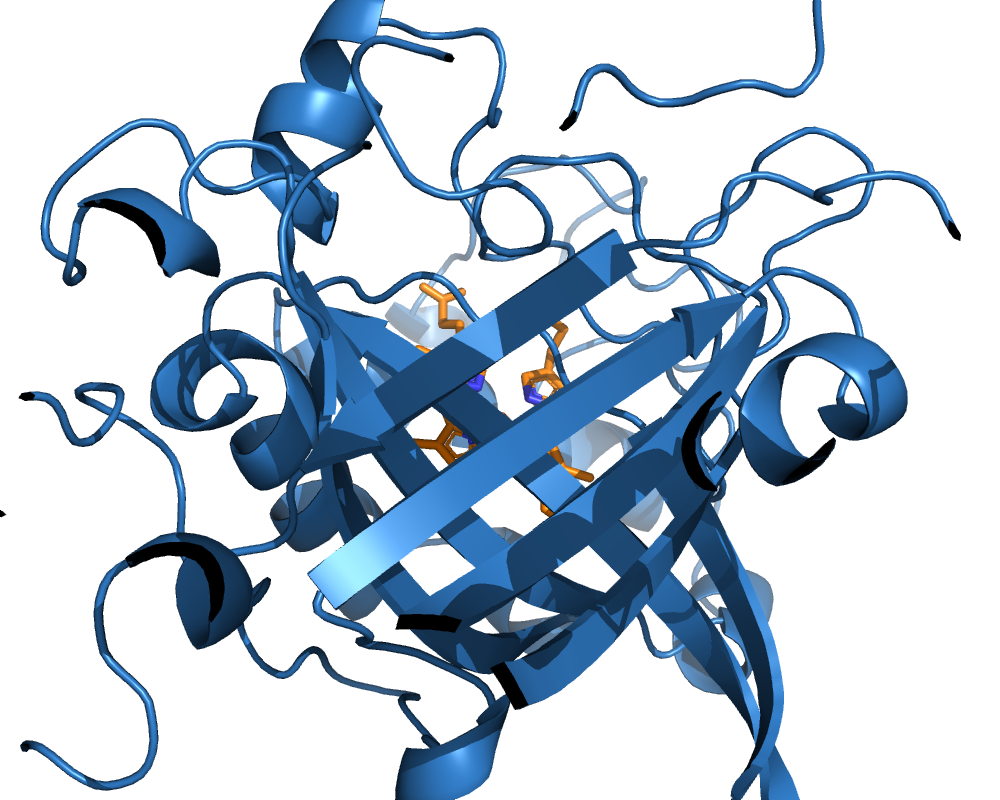

In [ ]:
from IPython.display import Image

# Use pymol2 as a context manager for robust startup/shutdown
with pymol2.PyMOL() as p:
    cmd = p.cmd

    cmd.load(merged_path, "bsdyp_receptor")
    cmd.hide("everything")
    cmd.show("cartoon", "polymer")
    cmd.color("skyblue", "polymer")
    cmd.show("sticks", "resn HEM")
    cmd.color("orange", "resn HEM")
    # Use explicit color command as an alternative to cmd.util.cnc
    cmd.color("atomic", "(resn HEM and not elem C)")

    cmd.bg_color("white")
    cmd.zoom("resn HEM", buffer=15)
    cmd.ray(1000, 800)
    cmd.png("BsDyP_haem_check.png", dpi=150)

# The 'with' statement handles p.stop() automatically when exiting the block.

Image("BsDyP_haem_check.png")

### BsDyP Summary Sheet

**Identity & provenance**
- Enzyme: BsDyP (dye-decolorizing peroxidase, EC 1.11.1.19)
- PDB ID: 7PKX
- Chain used: A (homodimer; both chains carry independent, non-interface heme pockets — A used arbitrarily, no ligand present to break the tie)
- Resolution: 2.491 Å
- Citation: Borges et al., 2021, *Int J Mol Sci* 22

**Box definition**
- Box centre source: fpocket pocket3, trimmed to atoms within 12 Å of heme Fe (removes elongation toward the substrate access channel while preserving the core binding cavity)
- Box centre (`cx, cy, cz`): 22.877, -18.147, -28.083
- Box size: 29 × 30 × 26 Å
- Validation check: pocket3 centroid at 1.92 Å from heme Fe (druggability score 0.922); box size larger than cotA/AzoR1, attributed to BsDyP's funnel-shaped substrate access channel to the buried heme (consistent with reported architecture), not treated as anomalous

**Structure prep decisions**
- Heme (HEM) cofactor: retained, merged into receptor as a rigid, non-rotatable block with uniform zero partial charge — unlike cotA's Cu centers (excluded entirely), HEM was kept because the reported MG-binding site sits at the heme γ-edge itself, making the porphyrin ring a structural wall of the pocket rather than a peripheral cofactor
- HEM PDBQT generation: built manually from verified PDB coordinates (element → AutoDock atom type mapping: C→C, N→N, O→OA, Fe→Fe), bypassing OpenBabel, which failed to parse Fe-porphyrin coordination bonds and produced an empty output
- Protonation: pH 7.0 (standard docking convention; note BsDyP's reported catalytic pH optimum for MG oxidation is ~4.0 — a pH-sensitivity re-dock is a candidate follow-up if results are ambiguous)
- Cleaning method: BioPython chain/residue `Select` filtering (consistent with cotA)
- Backbone gap: residues 112–116 unresolved in the crystal structure; confirmed >39 Å from heme Fe, not near the active site, no impact on docking
- Structural validation: heme position confirmed via PyMOL visualization — embedded within a beta-sheet-rich core, consistent with the DyP/CDE structural superfamily fold (distinct from the alpha-helical heme pocket of classical peroxidases), ruling out a malformed merge

**File paths**
- Raw PDB: `02_receptors/raw_pdb/7pkx.pdb`
- Cleaned, protein+HEM structure: `02_receptors/raw_pdb/7pkx_clean_protein_heme.pdb`
- Protonated structure: `02_receptors/raw_pdb/7pkx_protonated.pdb`
- Final receptor PDBQT: `02_receptors/prepared_pdbqt/BsDyP_receptor.pdbqt`

### SUMMARY FOR THE METHODS SECTION
The crystal structure of BsDyP (PDB ID: 7PKX, chain A, 2.49 Å resolution) [CITE Borges et al., 2021] was used as the receptor for docking simulations. The structure was cleaned to retain the protein backbone and the native heme (HEM) cofactor, with solvent molecules and hydrogens removed, and protonated at pH 7.0 using PDB2PQR (AMBER forcefield). Because the malachite green binding site has been reported to lie at the heme γ-edge [CITE Shrestha et al., 2020], the heme was retained as a rigid, non-rotatable component of the receptor rather than excluded, in contrast to metal cofactors lacking compatible force-field parameters (e.g., the type-1/2/3 copper centers of cotA). The docking search space was defined using a pocket detected by fpocket (druggability score 0.922), whose centroid lay 1.92 Å from the heme iron, with box dimensions (29 × 30 × 26 Å) derived from the pocket's spatial extent. The final receptor was converted to PDBQT format for use with AutoDock Vina, smina, and LeDock, and structurally validated by visual inspection to confirm correct heme placement prior to docking.

In [ ]:
!pwd

/content


In [ ]:
!pip install -q pymol-open-source

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 31.6 MB/s eta 0:00:00


In [ ]:
#import pymol2

#with pymol2.PyMOL() as p:
#    version_info = p.cmd.get_version()
#    print(f"PyMOL Version: {version_info[0]}.{version_info[1]}.{version_info[2]}")

PyMOL Version: 3.2.0a.3.0.3000000


In [ ]:
import pymol2

with pymol2.PyMOL() as p:
    version_info = p.cmd.get_version()

    print(version_info)

('3.2.0a', 3.0, 3000000, 1754317097, '7e6dafa700aba746ad963d5057748dbb8f87cbc6', 0)


In [ ]:
print(f"PyMOL Version: {version_info[0]}")

PyMOL Version: 3.2.0a
